# Materiały z Ekonometrii
**Autor:** Paulina Kania
---

In [2]:
# ============================================================
# INSTALACJA I IMPORT BIBLIOTEK
# ============================================================
# pip install numpy pandas scipy matplotlib seaborn statsmodels scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from scipy.stats import poisson, lognorm, norm, f as f_dist
import warnings
warnings.filterwarnings('ignore')

# Czytelniejszy styl wykresów
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('Biblioteki załadowane!')

Biblioteki załadowane!


---

## Laboratoria 1

---

### Zadanie 1

mamy relację sztywną: $oranges = family\_size + 1$.

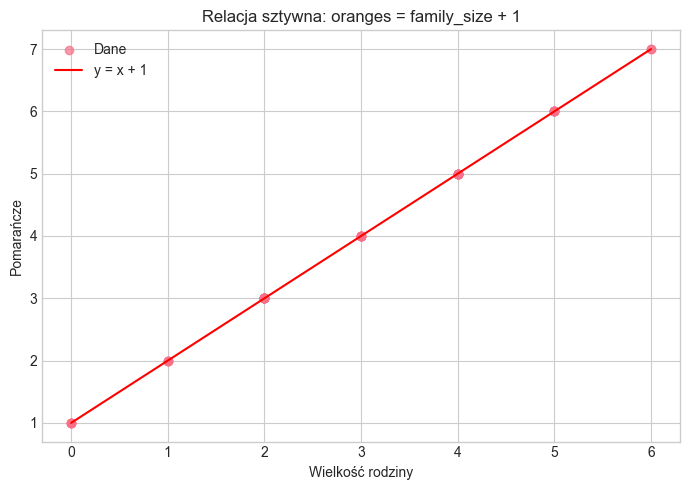

Korelacja Pearsona: 1.000000

--- BONUS: pełna macierz korelacji ---
             family_size  oranges
family_size          1.0      1.0
oranges              1.0      1.0


In [3]:
np.random.seed(111)

data = pd.DataFrame({
    'family_size': np.random.poisson(3, 50)
})
data['oranges'] = data['family_size'] + 1  # ilość pomarańcz = ilość osób w rodzinie + dzika pomarańcza

# Wykres + linia regresji
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(data['family_size'], data['oranges'], alpha=0.7, label='Dane')
x_line = np.linspace(data['family_size'].min(), data['family_size'].max(), 100)
ax.plot(x_line, x_line + 1, color='red', label='y = x + 1')
ax.set_xlabel('Wielkość rodziny'); ax.set_ylabel('Pomarańcze'); ax.legend()
ax.set_title('Relacja sztywna: oranges = family_size + 1')
plt.tight_layout(); plt.show()

# Korelacja
corr = data['family_size'].corr(data['oranges'])
print(f'Korelacja Pearsona: {corr:.6f}')

# BONUS: macierz korelacji jako heatmapa
print('\n--- BONUS: pełna macierz korelacji ---')
print(data.corr())

**Teoria:** Tutaj korelacja wynosi $1$. Każda zmiana $X$ (wielkość rodziny) powoduje przewidywalną zmianę $Y$. W ekonometrii takie modele prawie nie istnieją, bo ludzie nie są robotami.

---

### Zadanie 2

Tu wprowadzono funkcję get_preference. To jest kluczowy moment – dodajemy składnik losowy ($\varepsilon$).

**Praktyka:** Ludzie mają różne gusta (30% nie lubi pomarańczy, itd.). To sprawia, że kropki na wykresie nie leżą już w idealnej linii prostej.

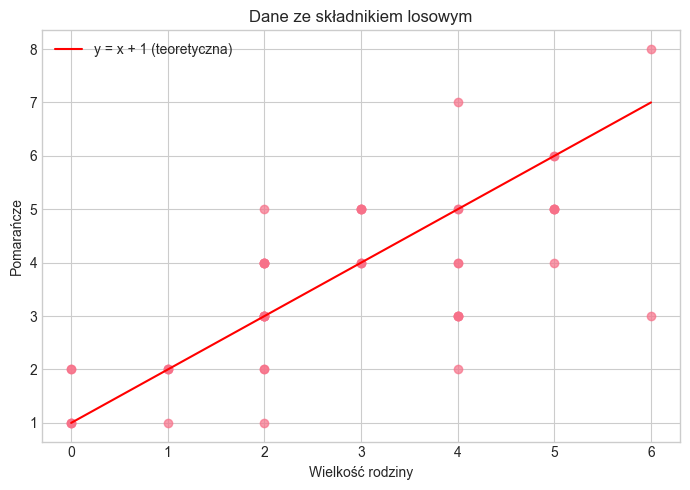

Korelacja: 0.7053


In [4]:
# Wprowadzam trochę losowości - ludzie mają różne preferencje
# 0 - nie lubi pomarańczy z prawdopodobieństwem 30%
# 1 - chce 1 pomarańcze z prawdopodobieństwem 50%
# 2 - chce 2 pomarańcze z prawdopodobieństwem 20%

def get_preference(family_sizes):
    """Dla każdej rodziny losuje ile pomarańczy kupi każdy członek."""
    result = []
    for x in family_sizes:
        choices = np.random.choice([0, 1, 2], size=x, replace=True, p=[0.3, 0.5, 0.2])
        result.append(choices.sum())
    return np.array(result)

np.random.seed(123)
data['oranges'] = get_preference(data['family_size'] + 1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(data['family_size'], data['oranges'], alpha=0.7)
x_line = np.linspace(data['family_size'].min(), data['family_size'].max(), 100)
ax.plot(x_line, x_line + 1, color='red', label='y = x + 1 (teoretyczna)')
ax.set_xlabel('Wielkość rodziny'); ax.set_ylabel('Pomarańcze')
ax.set_title('Dane ze składnikiem losowym'); ax.legend()
plt.tight_layout(); plt.show()

print(f'Korelacja: {data["family_size"].corr(data["oranges"]):.4f}')

#### Fundament Ekonometrii: **Metoda Najmniejszych Kwadratów (MNK)**

funkcja celu: $(y - a - bx)^2 \rightarrow min$.

**Teoria:** Python szuka takiej prostej (współczynników $a$ i $b$), aby suma kwadratów odległości między rzeczywistymi punktami ($y$) a prostą regresji ($\hat{y}$) była jak najmniejsza.

Dlaczego kwadrat? żeby błędy dodatnie (ktoś kupił więcej) i ujemne (ktoś kupił mniej) nie znosiły się nawzajem.

Suma kwadratów błędów (teoretyczna): 78.00


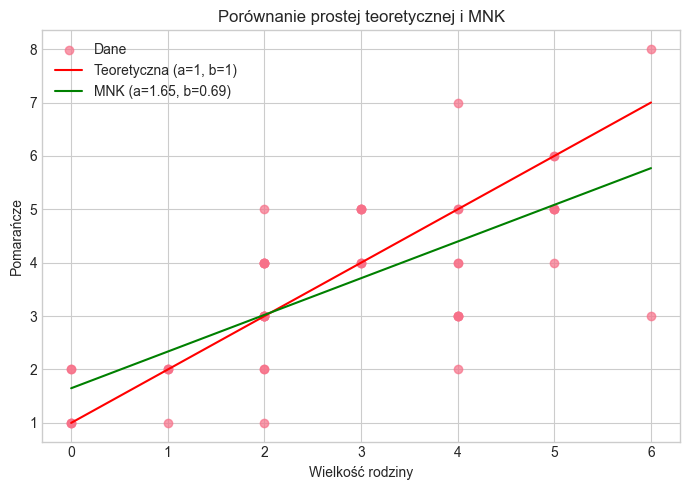

Suma kwadratów reszt (MNK): 62.31

--- Statystyki opisowe ---
       family_size   oranges     y_drop          e
count    50.000000  50.00000  50.000000  50.000000
mean      2.840000   3.60000   3.840000  -0.240000
std       1.633326   1.59079   1.633326   1.238168
min       0.000000   1.00000   1.000000  -4.000000
25%       2.000000   2.25000   3.000000  -1.000000
50%       3.000000   4.00000   4.000000   0.000000
75%       4.000000   5.00000   5.000000   1.000000
max       6.000000   8.00000   7.000000   2.000000

--- Podsumowanie modelu ---
                            OLS Regression Results                            
Dep. Variable:                oranges   R-squared:                       0.497
Model:                            OLS   Adj. R-squared:                  0.487
Method:                 Least Squares   F-statistic:                     47.52
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           1.07e-08
Time:                        22:48:01   Log-Likelihood:

In [5]:
# y = a + bx + e
# Metoda najmniejszych kwadratów: (y - a - bx)^2 -> min

# Teoretyczna prognoza: rodzina kupi tyle pomarańczy co członków + 1
data['y_drop'] = data['family_size'] + 1

# e - błędy, reszty (residuals)
data['e'] = data['oranges'] - data['y_drop']

print(f'Suma kwadratów błędów (teoretyczna): {(data["e"]**2).sum():.2f}')

# MNK - model w którym oranges zależą od family_size
X = sm.add_constant(data['family_size'])
model = sm.OLS(data['oranges'], X).fit()

a_hat = model.params['const']
b_hat = model.params['family_size']

# Wykres z obiema prostymi
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(data['family_size'], data['oranges'], alpha=0.7, label='Dane')
x_line = np.linspace(data['family_size'].min(), data['family_size'].max(), 100)
ax.plot(x_line, x_line + 1, color='red', label='Teoretyczna (a=1, b=1)')
ax.plot(x_line, a_hat + b_hat*x_line, color='green', label=f'MNK (a={a_hat:.2f}, b={b_hat:.2f})')
ax.legend(); ax.set_xlabel('Wielkość rodziny'); ax.set_ylabel('Pomarańcze')
ax.set_title('Porównanie prostej teoretycznej i MNK')
plt.tight_layout(); plt.show()

print(f'Suma kwadratów reszt (MNK): {(model.resid**2).sum():.2f}')
print('\n--- Statystyki opisowe ---')
print(data.describe())
print('\n--- Podsumowanie modelu ---')
print(model.summary())

# t = (m - m0)/S*sqrt(n) ~ tS(n-1)
print(f'\nt-value (obliczone ręcznie): {1.0823/0.3473:.4f}')

#### Interpretacja Wyników **model.summary()**

**coef (const)** - Wyraz wolny ($a$) - Ile pomarańczy kupi "rodzina" o rozmiarze 0.

**coef (family_size)** - Współczynnik kierunkowy ($b$) - O ile sztuk wzrośnie zakup pomarańczy, jeśli rodzina powiększy się o 1 osobę.

**std err** - Błąd standardowy - Jak bardzo mylimy się w oszacowaniu parametrów.

**t** - Statystyka t - Testujemy $H_0: b = 0$. Jeśli $|t| > 2$, wpływ jest istotny.

**P>|t|** - p-value - Jeśli $< 0.05$, zmienna jest istotna statystycznie.

**R-squared** - Współczynnik determinacji - Jaki procent zmienności $Y$ wyjaśnia model.

**F-statistic** - Test łącznej istotności wszystkich zmiennych.

---

### Zadanie 3

Trzy kluczowe koncepcje: zmienne binarne (zero-jedynkowe), interakcje oraz współliniowość

**Wersja I**

**Teoria:** Współczynnik przy `sale` ($\beta_2$) mówi nam o ile średnio zmienia się liczba pomarańczy, gdy pojawia się wyprzedaż, zakładając, że wielkość rodziny jest stała.

                            OLS Regression Results                            
Dep. Variable:                oranges   R-squared:                       0.641
Model:                            OLS   Adj. R-squared:                  0.626
Method:                 Least Squares   F-statistic:                     41.96
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           3.51e-11
Time:                        22:48:01   Log-Likelihood:                -80.541
No. Observations:                  50   AIC:                             167.1
Df Residuals:                      47   BIC:                             172.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.3862      0.379      1.018      

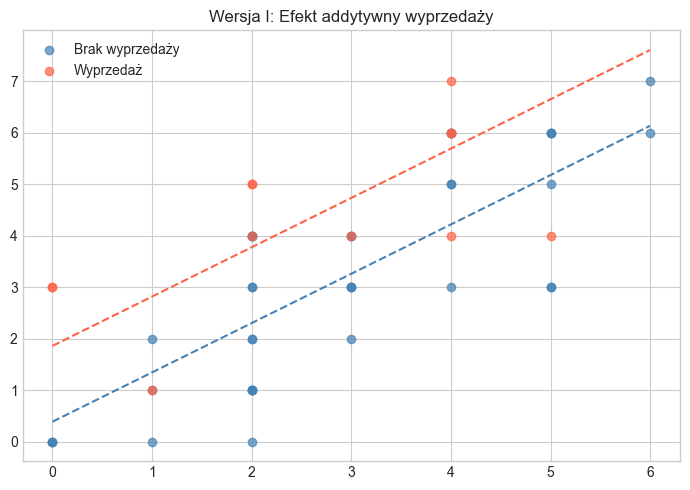

In [6]:
# Wyprzedaż:
# wersja I (liniowa): jeśli jest wyprzedaż, ludzie biorą jedną pomarańcze więcej
# wersja II: interakcyjna - więcej pomarańczy na każdego kupującego

np.random.seed(456)
# na 70% nie ma wyprzedaży, na 30% jest
data['sale'] = np.random.choice([0, 1], 50, replace=True, p=[0.7, 0.3])

# Wersja I: Addytywna - każdy kupuje o jedną pomarańcze więcej
data['oranges'] = get_preference(data['family_size'] + 1) + data['sale']

model = smf.ols('oranges ~ family_size + sale', data=data).fit()
print(model.summary())
# o jeden członek rodziny więcej -> o .96 większe zakupy

# BONUS: wizualizacja efektu wyprzedaży
fig, ax = plt.subplots(figsize=(7, 5))
for sale_val, color, label in [(0, 'steelblue', 'Brak wyprzedaży'), (1, 'tomato', 'Wyprzedaż')]:
    subset = data[data['sale'] == sale_val]
    ax.scatter(subset['family_size'], subset['oranges'], color=color, alpha=0.7, label=label)
a, b, c = model.params['Intercept'], model.params['family_size'], model.params['sale']
x_line = np.linspace(0, data['family_size'].max(), 100)
ax.plot(x_line, a + b*x_line, color='steelblue', linestyle='--')
ax.plot(x_line, a + c + b*x_line, color='tomato', linestyle='--')
ax.legend(); ax.set_title('Wersja I: Efekt addytywny wyprzedaży')
plt.tight_layout(); plt.show()

**Wersja II**

**Praktyka:** Wersja II (interakcyjna) zakłada, że wyprzedaż działa silniej na duże rodziny (kupują "agresywniej").

In [7]:
# Wersja II: Im większa rodzina, tym większa reakcja na wyprzedaż
# y = a + bx + cz + e
data['oranges'] = get_preference(data['family_size'] + 1) * (1 + data['sale'])

# family_size*sale tworzy zmienną interakcyjną
model = smf.ols('oranges ~ family_size * sale', data=data).fit()
# Z każdą osobą więcej mamy o 0.75 zakupów więcej, a gdy jest wyprzedaż to o 0.86
# Współczynnik interakcji jest dodatni - przy wyprzedaży duże rodziny kupują agresywniej
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                oranges   R-squared:                       0.557
Model:                            OLS   Adj. R-squared:                  0.528
Method:                 Least Squares   F-statistic:                     19.25
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           3.12e-08
Time:                        22:48:01   Log-Likelihood:                -104.08
No. Observations:                  50   AIC:                             216.2
Df Residuals:                      46   BIC:                             223.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            1.1351      0.679  

In [8]:
# Współliniowość (Collinearity) - gdy jedna zmienna jest kombinacją innej
data['z'] = 4 + 3 * data['family_size']
model = smf.ols('oranges ~ family_size + sale + z', data=data).fit()
print('=== PEŁNA WSPÓŁLINIOWOŚĆ ===')
print(model.params)  # NaN - pełna współliniowość, nie da się obliczyć

# Dodajemy szum - niepełna współliniowość
data['z'] = 4 + 3 * data['family_size'] + np.random.normal(0.5, 1, 50)
model = smf.ols('oranges ~ family_size + sale + z', data=data).fit()
print('\n=== NIEPEŁNA WSPÓŁLINIOWOŚĆ (z szumem) ===')
print(model.summary())

=== PEŁNA WSPÓŁLINIOWOŚĆ ===
Intercept     -0.243934
family_size    0.401341
sale           3.191396
z              0.228290
dtype: float64

=== NIEPEŁNA WSPÓŁLINIOWOŚĆ (z szumem) ===
                            OLS Regression Results                            
Dep. Variable:                oranges   R-squared:                       0.532
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     17.42
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           1.07e-07
Time:                        22:48:01   Log-Likelihood:                -105.44
No. Observations:                  50   AIC:                             218.9
Df Residuals:                      46   BIC:                             226.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    

---

### Zadanie 4

**Błąd I Rodzaju (Alfa $\alpha$)** - W statystyce przyjmujemy poziom istotności ($\alpha = 0.05$).

**Teoria:** Akceptujesz 5% szansy na to, że uznasz coś za prawdę, mimo że to tylko przypadek.

**Praktyka:** Jeśli badasz wpływ temperatury na pomarańcze, a w rzeczywistości temperatura nie ma żadnego znaczenia, to w 5 na 100 badań i tak wyjdzie Ci, że "wpływa".

In [9]:
np.random.seed(789)

# Czy temperatura wpływa na to czy ludzie kupują pomarańcze?
data['temp'] = np.random.normal(15, 5, 50)

model = smf.ols('oranges ~ family_size * sale + temp', data=data).fit()
print(f'p-value dla temp: {model.pvalues["temp"]:.4f}')
# Wysokie, więc wnioskujemy że nie jest istotnie powiązana

# SYMULACJA "Błędu I Rodzaju" - Eksperyment Monte Carlo
# Błąd I Rodzaju (False Positive): odrzucasz H0, mimo że jest prawdziwa
# P-hacking: testując wystarczająco dużo zmiennych, któraś "wyjdzie" jako istotna

# ZADANIE:
# symulacja 1000 razy
# losowanie zmiennej niepowiązanej z y
# estymacja modelu
# liczymy ile razy p-value tej zmiennej było mniejsze niż 5%

count = 0
for i in range(1000):
    a = np.random.choice(range(1, 101), 50)
    df_temp = data.copy()
    df_temp['a'] = a
    m = smf.ols('oranges ~ family_size + a', data=df_temp).fit()
    if m.pvalues['a'] < 0.05:
        count += 1

print(f'\nLiczba fałszywych alarmów (na 1000): {count}')
print('Skoro zmienna a jest losowa, powinna być nieistotna.')
print(f'Jednak przy α=0.05 spodziewamy się ~50 trafień = {count/1000*100:.1f}%')
# Wniosek: przy 20 bzdurnych zmiennych jedna "wyjdzie" -> P-hacking!

p-value dla temp: 0.9497

Liczba fałszywych alarmów (na 1000): 47
Skoro zmienna a jest losowa, powinna być nieistotna.
Jednak przy α=0.05 spodziewamy się ~50 trafień = 4.7%


**P-hacking i Eksperyment Monte Carlo**

1. Pętla for: Powtarza badanie 1000 razy.
2. Zmienna `a`: Jest generowana całkowicie losowo. Wiemy na 100%, że nie ma ona nic wspólnego z pomarańczami.
3. Warunek if: Sprawdza, czy p-value spadło poniżej 0.05.

Wynik: Licznik zazwyczaj pokaże wartość bliską 50 (5% z 1000).

$\rightarrow$ **Wniosek:** Nawet jeśli zmienna jest bez sensu, statystyka "oszuka" Cię w 5% przypadków.

---

### Zadanie 5

In [10]:
# Regresja pozorna (Spurious Regression) - zależne od trendów czasowych
# Tworzymy x i y, które nie mają ze sobą NIC wspólnego,
# ale obie mają trend AR(1): wartość zależy od poprzedniej * 0.9

count = 0
for j in range(1000):
    x = np.zeros(200)
    y = np.zeros(200)
    x[0] = 1
    y[0] = 1
    for i in range(1, 200):
        x[i] = 0.9 * x[i-1] + np.random.normal()
        y[i] = 0.9 * y[i-1] + np.random.normal()
    df_temp = pd.DataFrame({'x': x, 'y': y})
    m = smf.ols('y ~ x', data=df_temp).fit()
    if m.pvalues['x'] < 0.05:
        count += 1

print(f'Regresja pozorna - "istotne" wyniki: {count}/1000 ({count/10:.1f}%)')
print('Wniosek: Korelacja ≠ Przyczynowość!')
print('Test t-Studenta drastycznie zawodzi dla szeregów z trendem.')

Regresja pozorna - "istotne" wyniki: 505/1000 (50.5%)
Wniosek: Korelacja ≠ Przyczynowość!
Test t-Studenta drastycznie zawodzi dla szeregów z trendem.


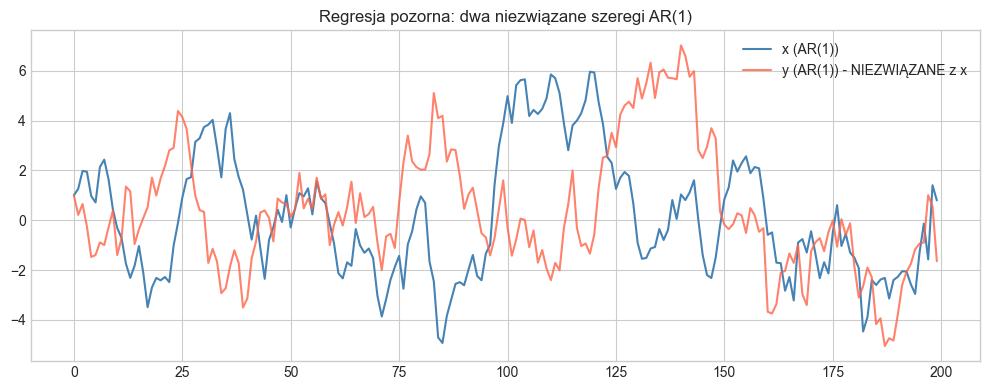

In [11]:
# Wykres dwóch niezwiązanych szeregów AR(1)
x = np.zeros(200)
y = np.zeros(200)
x[0] = 1; y[0] = 1
for i in range(1, 200):
    x[i] = 0.9 * x[i-1] + np.random.normal()
    y[i] = 0.9 * y[i-1] + np.random.normal()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, label='x (AR(1))', color='steelblue')
ax.plot(y, label='y (AR(1)) - NIEZWIĄZANE z x', color='tomato', alpha=0.8)
ax.legend(); ax.set_title('Regresja pozorna: dwa niezwiązane szeregi AR(1)')
plt.tight_layout(); plt.show()

**Korelacja $\neq$ Przyczynowość**: Dwie zmienne mogą być silnie skorelowane tylko dlatego, że obie rosną lub spadają w czasie.

---

## Laboratoria 2

---

### Zadanie 1

In [12]:
n_days = 20

np.random.seed(111)
days = pd.DataFrame({
    'day_nr': range(1, n_days + 1),
    'weekend': np.random.choice([0, 1], n_days, replace=True, p=[5/7, 2/7]),
    'temp': np.random.normal(25, 3, n_days),
    'wind': np.random.lognormal(1.5, 1, n_days)
})

# deszcz: większe prawdopodobieństwo, gdy temperatura jest niższa
def rain_for_temp(t):
    p_no_rain = (50 + t) / 100
    p_rain = (50 - t) / 100
    p_rain = max(0, min(p_rain, 1))
    p_no_rain = 1 - p_rain
    event = np.random.choice([0, 1], p=[p_no_rain, p_rain])
    return event * np.random.poisson(5)

days['rain'] = days['temp'].apply(rain_for_temp)

np.random.seed(222)
n_shops = 20
shops = pd.DataFrame({
    'shop': range(1, n_shops + 1),
    'exp': np.random.poisson(5, n_shops),
    'beach': np.random.lognormal(2.5, 1.5, n_shops) * 10,
    'flavors': np.random.poisson(3, n_shops) + 4,
    'parking': np.random.choice([0, 1], n_shops, replace=True)
})

# Lodziarnie przy plaży nie mają parkingów
shops.loc[shops['beach'] < 200, 'parking'] = 0
shops['price'] = np.where(shops['beach'] < 200, 7, 6) + \
                 np.random.choice([-1, 0, 1], n_shops, replace=True)
shops['other'] = shops['beach'].apply(
    lambda x: np.random.lognormal(np.log(x / 50), 0.5) * 10
)

data = days.merge(shops, how='cross')  # iloczyn kartezjański jak merge(by=NULL) w R

# Sprzedaż: zależna od wielu czynników
data['sales'] = (
    2000 + 10*data['temp'] - 40*data['rain'] - 0.1*data['beach'] +
    0.05*data['other'] - 7*data['price'] + 30*data['weekend'] +
    5*data['temp']*data['weekend'] + 10*(data['exp']-4)**2 +
    5*(data['flavors']-7)**2 + np.random.normal(0, 50, len(data))
)

data = data.drop(columns=['day_nr', 'shop'])  # usuwamy niepotrzebne kolumny
print(f'Kształt danych: {data.shape}')
data.head()

Kształt danych: (400, 11)


,weekend,temp,wind,rain,exp,beach,flavors,parking,price,other,sales
0,0,26.476009,7.546484,3,5,10.724808,8,0,6,4.817930,2124.810831
1,0,26.476009,7.546484,3,5,100.305087,9,0,8,23.515005,2066.716736
2,0,26.476009,7.546484,3,5,218.190088,8,0,7,152.853269,2114.148694
3,0,26.476009,7.546484,3,4,151.898665,5,0,7,74.204774,2061.516745
4,0,26.476009,7.546484,3,4,188.685445,5,0,8,38.767812,2022.937160


---

### Zadanie 2

Specyfikacja Modelu

In [13]:
# ===== krok 1: przegląd danych
print(data.describe())

          weekend        temp        wind        rain         exp  \
count  400.000000  400.000000  400.000000  400.000000  400.000000   
mean     0.150000   25.283375   10.460630    1.500000    5.450000   
std      0.357519    2.978317   14.729393    2.358794    2.227083   
min      0.000000   19.991978    0.783610    0.000000    1.000000   
25%      0.000000   23.596966    2.909741    0.000000    4.000000   
50%      0.000000   25.372058    4.337724    0.000000    5.000000   
75%      0.000000   26.534952    8.074813    2.250000    7.000000   
max      1.000000   32.184069   60.169427    9.000000   10.000000   

             beach     flavors     parking       price       other  \
count   400.000000  400.000000  400.000000  400.000000  400.000000   
mean    224.759024    7.150000    0.150000    6.900000   56.007656   
std     244.849571    1.591802    0.357519    0.769077   60.976723   
min       4.386444    4.000000    0.000000    6.000000    0.380102   
25%      61.644345    6.0000

In [14]:
# ===== krok 2: przegląd zależności między zmiennymi
print(data.corr().round(3))

         weekend   temp   wind   rain    exp  beach  flavors  parking  price  \
weekend    1.000 -0.251 -0.119 -0.030 -0.000 -0.000   -0.000   -0.000  0.000   
temp      -0.251  1.000 -0.195  0.078 -0.000 -0.000   -0.000    0.000 -0.000   
wind      -0.119 -0.195  1.000 -0.214 -0.000  0.000    0.000    0.000  0.000   
rain      -0.030  0.078 -0.214  1.000  0.000  0.000    0.000    0.000  0.000   
exp       -0.000 -0.000 -0.000  0.000  1.000  0.036    0.122    0.041  0.231   
beach     -0.000 -0.000  0.000  0.000  0.036  1.000   -0.145    0.165 -0.273   
flavors   -0.000 -0.000  0.000  0.000  0.122 -0.145    1.000    0.313 -0.151   
parking   -0.000  0.000  0.000  0.000  0.041  0.165    0.313    1.000 -0.310   
price      0.000 -0.000  0.000  0.000  0.231 -0.273   -0.151   -0.310  1.000   
other      0.000 -0.000  0.000  0.000  0.121  0.851   -0.194   -0.009 -0.211   
sales      0.333  0.082  0.055 -0.623  0.381 -0.217    0.066    0.016  0.070   

         other  sales  
weekend  0.000 

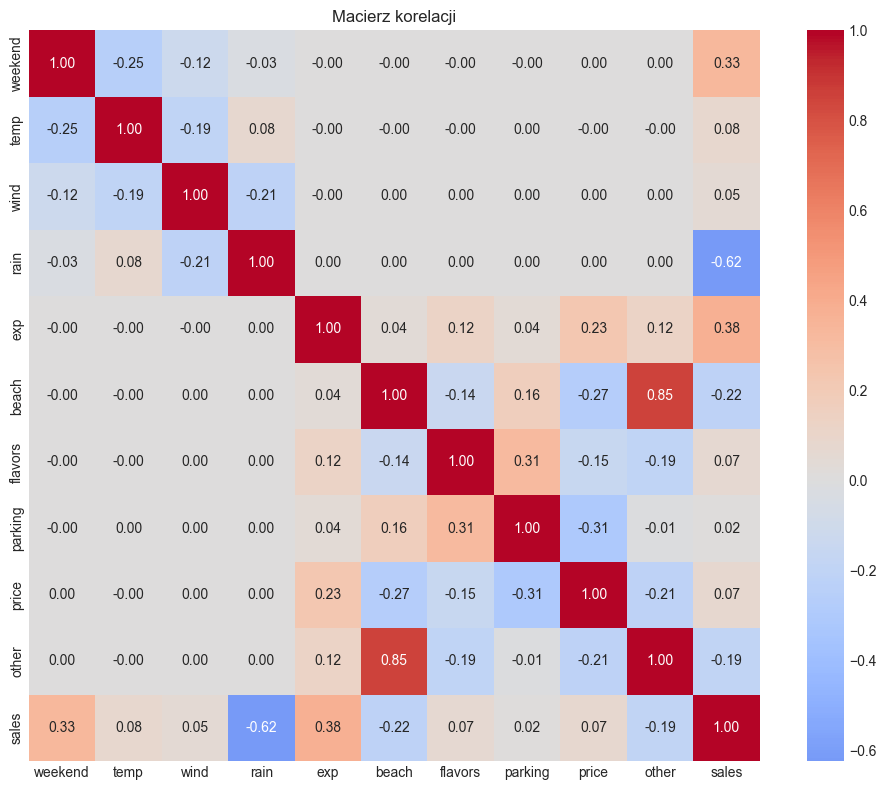

In [15]:
# Heatmapa korelacji
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax)
ax.set_title('Macierz korelacji')
plt.tight_layout(); plt.show()

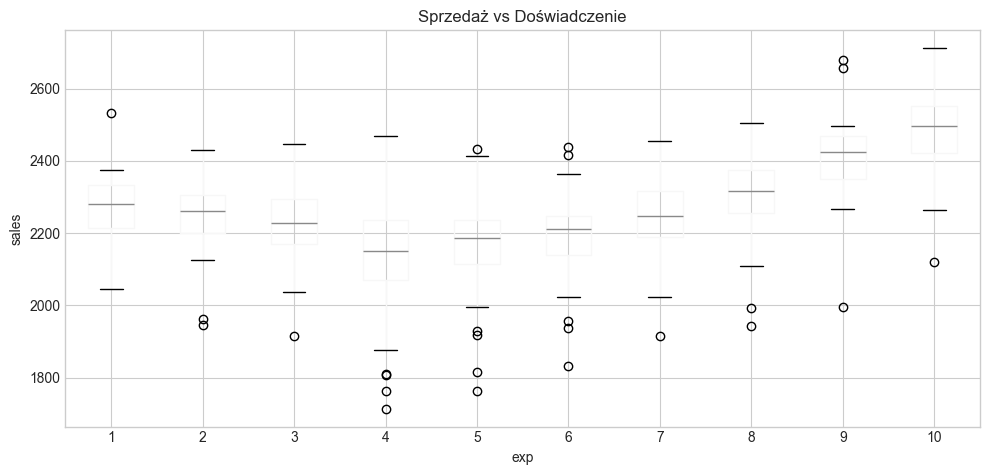

In [16]:
# Sprzedaż względem kategorii doświadczenia (boxplot jak w R)
fig, ax = plt.subplots(figsize=(10, 5))
data.boxplot(column='sales', by='exp', ax=ax)
ax.set_title('Sprzedaż vs Doświadczenie'); ax.set_xlabel('exp'); ax.set_ylabel('sales')
plt.suptitle('')
plt.tight_layout(); plt.show()

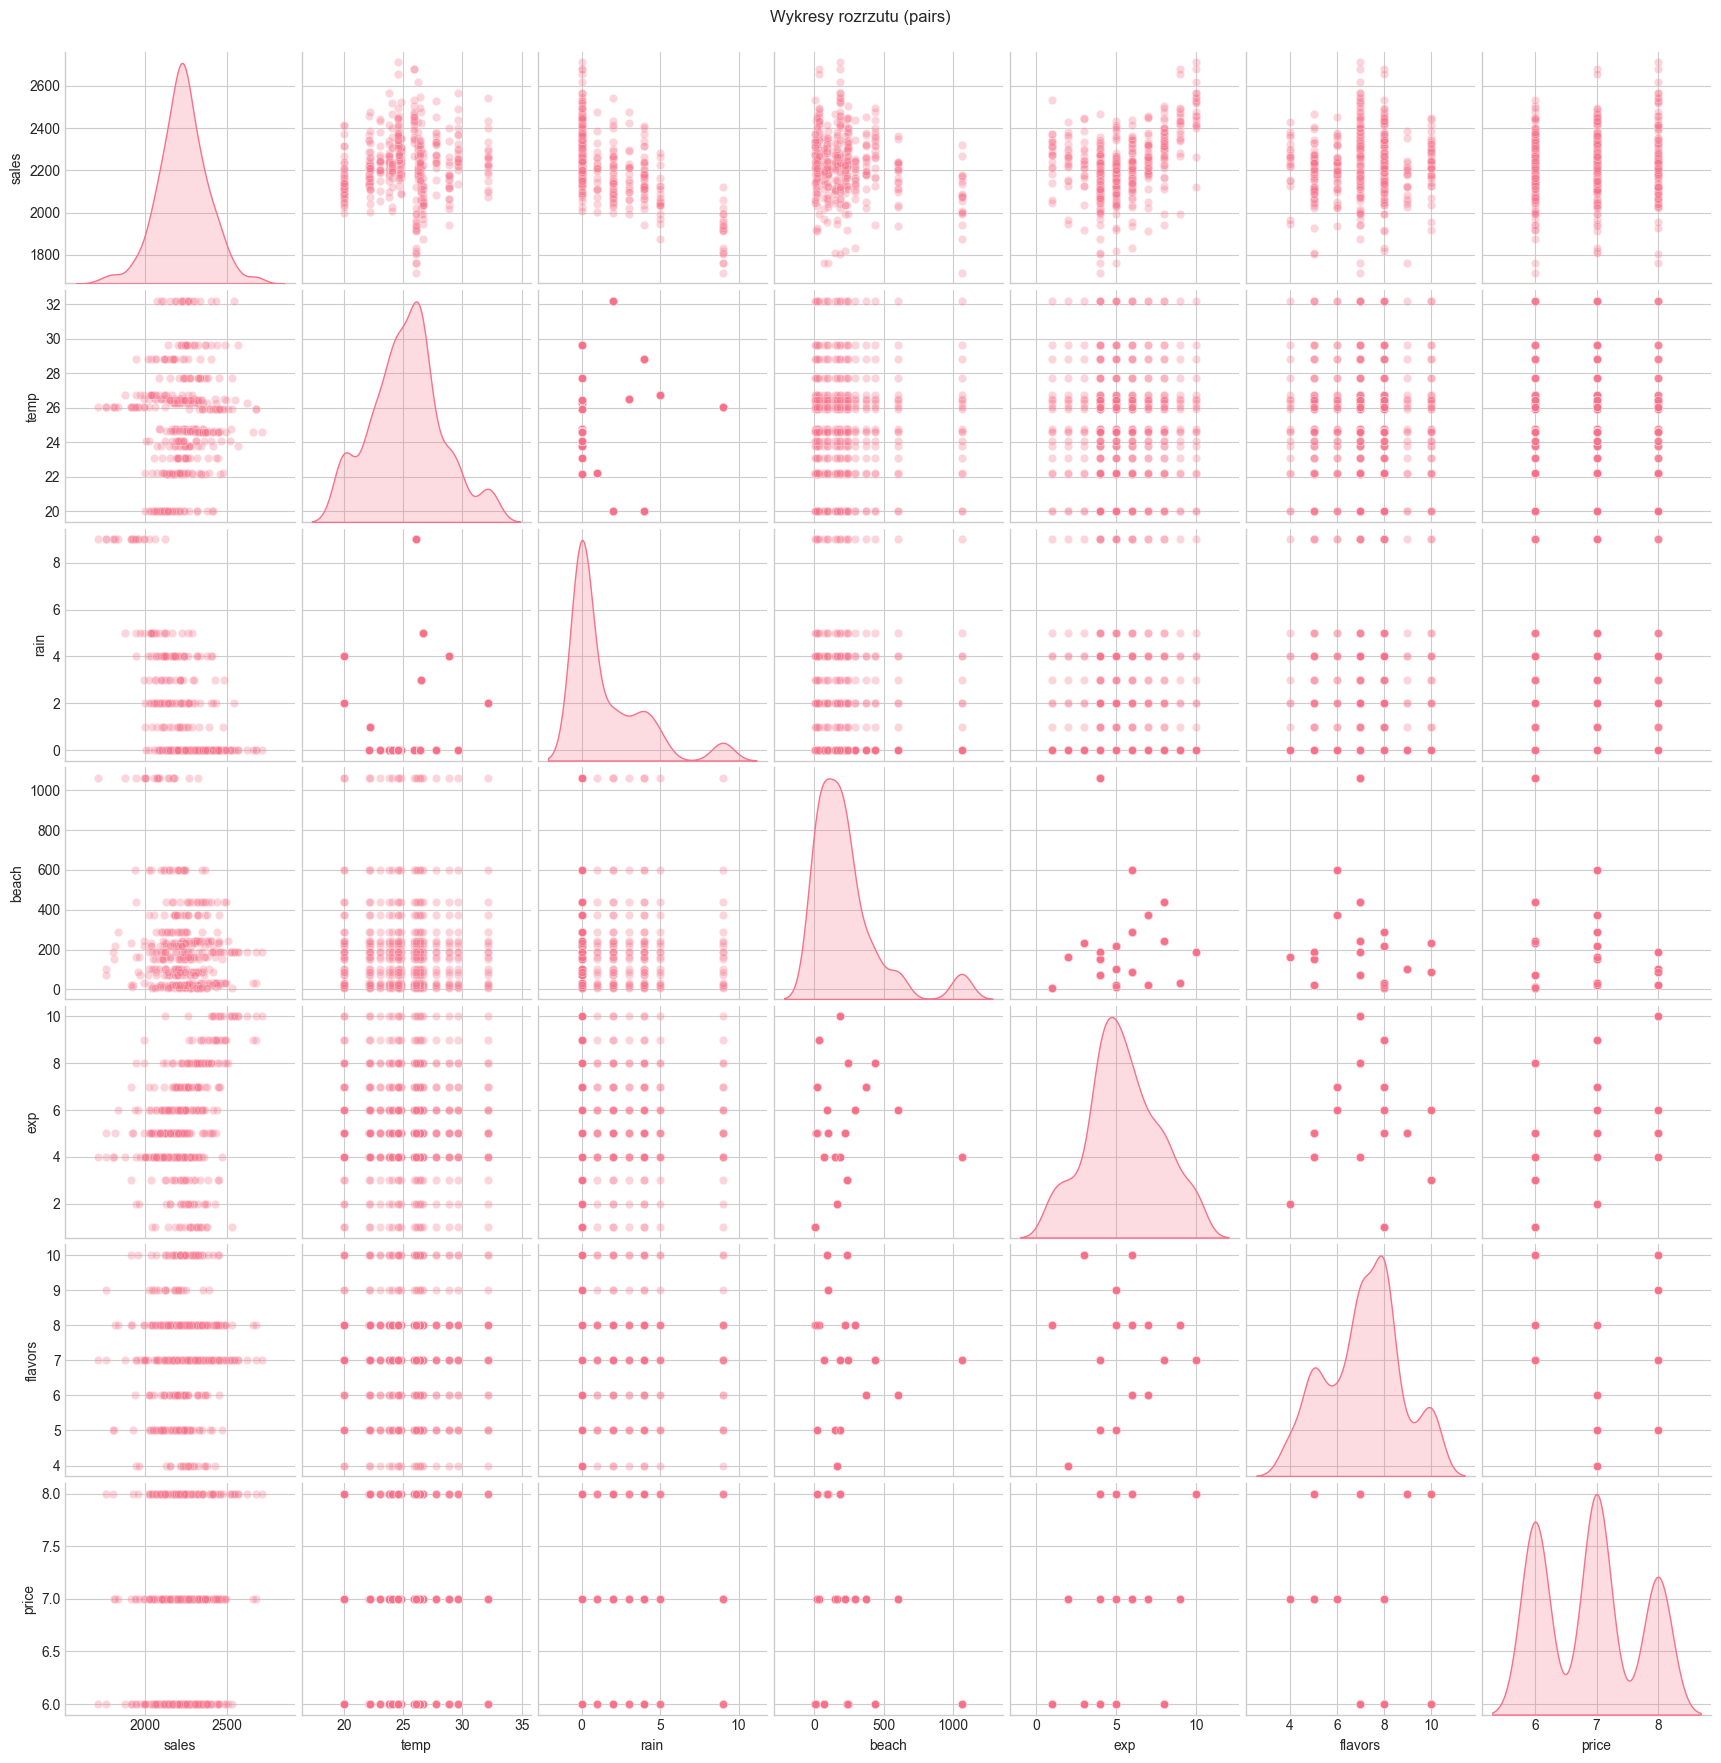

In [17]:
# Wykresy rozrzutu (pairs plot)
cols_to_plot = ['sales', 'temp', 'rain', 'beach', 'exp', 'flavors', 'price']
fig = sns.pairplot(data[cols_to_plot], plot_kws={'alpha': 0.3}, diag_kind='kde')
fig.fig.suptitle('Wykresy rozrzutu (pairs)', y=1.01)
plt.show()

In [18]:
model = smf.ols('sales ~ weekend + temp + wind + rain + exp + beach + flavors + parking + price + other', data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     115.7
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          5.42e-110
Time:                        22:48:18   Log-Likelihood:                -2297.5
No. Observations:                 400   AIC:                             4617.
Df Residuals:                     389   BIC:                             4661.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2038.6034     58.401     34.907      0.0

**VIF (Variance Inflation Factor)** – Wykrywacz "Złodziei Istotności"

**Teoria:** VIF mierzy, jak bardzo wariancja współczynnika jest "nadmuchana" przez współliniowość.

**Interpretacja:** Jeśli $VIF > 5$, zmienne są tak silnie powiązane, że model nie potrafi precyzyjnie obliczyć ich indywidualnego wpływu.

VIF - problem jeśli > 5:
   Feature       VIF
5    beach  4.176250
9    other  4.169830
7  parking  1.340929
8    price  1.313282
6  flavors  1.215548
4      exp  1.169185
1     temp  1.129514
2     wind  1.121560
0  weekend  1.104197
3     rain  1.051992


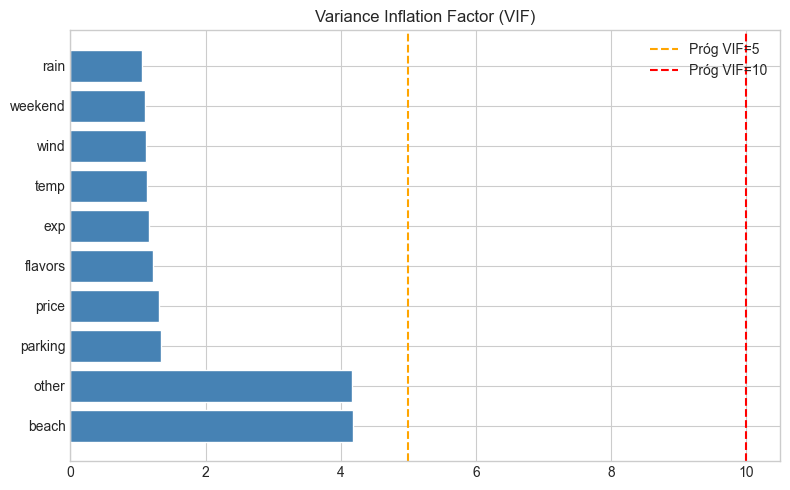

In [19]:
# ===== krok 3: współliniowość
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(df, target_col):
    """Oblicza VIF dla wszystkich zmiennych objaśniających."""
    features = [c for c in df.columns if c != target_col]
    X = sm.add_constant(df[features])
    vif_data = pd.DataFrame({
        'Feature': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    }).query('Feature != "const"').reset_index(drop=True)
    return vif_data.sort_values('VIF', ascending=False)

vif_df = calc_vif(data, 'sales')
print('VIF - problem jeśli > 5:')
print(vif_df)

# BONUS: wizualizacja VIF
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato' if v > 5 else 'steelblue' for v in vif_df['VIF']]
ax.barh(vif_df['Feature'], vif_df['VIF'], color=colors)
ax.axvline(5, color='orange', linestyle='--', label='Próg VIF=5')
ax.axvline(10, color='red', linestyle='--', label='Próg VIF=10')
ax.legend(); ax.set_title('Variance Inflation Factor (VIF)')
plt.tight_layout(); plt.show()

In [20]:
# Model bez other (wysoki VIF)
model = smf.ols('sales ~ weekend + temp + wind + rain + exp + beach + flavors + parking + price', data=data).fit()
print(model.summary())

# Przekształcenie zmiennej - regresja wielomianowa
# I(...) w R odpowiada bezpośredniemu przekształceniu w formule
data['exp_poly'] = (data['exp'] - data['exp'].median())**2
model = smf.ols('sales ~ weekend + temp + wind + rain + exp_poly + beach + flavors + parking + price', data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.737
Method:                 Least Squares   F-statistic:                     125.0
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          4.00e-109
Time:                        22:48:18   Log-Likelihood:                -2302.1
No. Observations:                 400   AIC:                             4624.
Df Residuals:                     390   BIC:                             4664.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2022.3771     58.749     34.424      0.0

In [21]:
# Zmienna kategoryczna
data['exp_cat'] = data['exp'].astype('category')
model = smf.ols('sales ~ weekend + temp + wind + rain + C(exp) + beach + flavors + parking + price', data=data).fit()
print(model.summary())

vif_df2 = calc_vif(data.drop(columns=['exp_cat', 'exp_poly']), 'sales')
print('\nVIF po przekształceniu:')
print(vif_df2)

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     202.5
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          3.76e-179
Time:                        22:48:18   Log-Likelihood:                -2112.7
No. Observations:                 400   AIC:                             4261.
Df Residuals:                     382   BIC:                             4333.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     2040.4296     46.071     44.288   

---

### Zadanie 3

#### **Metoda Hellwiga**

Metoda Hellwiga służy do doboru zmiennych objaśniających:
1. Wysoką korelację z $Y$
2. Niską korelację między sobą

$$h_i = \frac{r_{j}^2}{\sum_{j \in K} |r_{ij}|}$$

In [22]:
# METODA HELLWIGA

from itertools import combinations

numeric_data = data.select_dtypes(include=np.number).drop(columns=['exp_poly'], errors='ignore')
feature_cols = [c for c in numeric_data.columns if c != 'sales']

corr_matrix = numeric_data.corr()
R0 = corr_matrix.loc[feature_cols, 'sales']   # korelacje zmiennych z Y
R  = corr_matrix.loc[feature_cols, feature_cols]  # korelacje między zmiennymi

print('Korelacje z sales (R0):')
print(R0.sort_values(ascending=False))

best_H = -np.inf
best_combo = []

n_vars = len(feature_cols)

for r in range(1, n_vars + 1):
    for combo in combinations(range(n_vars), r):
        k = list(combo)
        H = 0
        for i in k:
            mianownik = sum(abs(R.iloc[i, j]) for j in k)
            if mianownik > 0:
                H += R0.iloc[i]**2 / mianownik
        if H > best_H:
            best_H = H
            best_combo = [feature_cols[i] for i in k]

print(f'\nMaksymalna pojemność informacyjna H: {best_H:.4f}')
print(f'Optymalne zmienne: {best_combo}')

Korelacje z sales (R0):
exp        0.381372
weekend    0.333065
temp       0.082500
price      0.070003
flavors    0.065525
wind       0.054980
parking    0.015864
other     -0.186593
beach     -0.216632
rain      -0.622712
Name: sales, dtype: float64

Maksymalna pojemność informacyjna H: 0.6700
Optymalne zmienne: ['weekend', 'rain', 'exp', 'beach']


---

## Laboratoria 3

---

### Zadanie 1

#### Diagnostyka

Reszta: $e = y - \hat{y}$

Główne problemy:
- **współliniowość** - VIF > 5 to czerwona flaga
- **normalność reszt** - Shapiro-Wilk, p > 0.05 = normalne
- **homoskedastyczność** - Breusch-Pagan, p < 0.05 = problem
- **postać liniowa** - test RESET
- **autokorelacja** - test serii losowości

In [23]:
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.stattools import durbin_watson
from statsmodels.sandbox.stats.runs import runstest_1samp
from statsmodels.stats.outliers_influence import variance_inflation_factor

def test_summary(model, data_df=None):
    """Odpowiednik test_summary() z R."""
    r = model.resid
    print('=' * 55)
    print('DIAGNOSTYKA MODELU')
    print('=' * 55)
    
    # Współliniowość
    X_df = model.model.exog
    feat_names = model.model.exog_names
    non_const = [(n, i) for i, n in enumerate(feat_names) if n != 'Intercept']
    if len(non_const) > 1:
        vif_vals = {n: variance_inflation_factor(X_df, i) for n, i in non_const}
        print('\nVIF (współliniowość, > 5 = problem):')
        for k, v in vif_vals.items():
            flag = ' *** PROBLEM' if v > 5 else ''
            print(f'  {k}: {v:.3f}{flag}')
    
    # Normalność reszt
    stat, p = stats.shapiro(r)
    print(f'\nShapiro-Wilk (normalność reszt):')
    print(f'  W={stat:.4f}, p={p:.4f}  {"✓ ok" if p > 0.05 else "✗ brak normalności"}')
    
    # Heteroskedastyczność (Breusch-Pagan)
    _, bp_p, _, _ = het_breuschpagan(r, model.model.exog)
    print(f'\nBreusch-Pagan (heteroskedastyczność):')
    print(f'  p={bp_p:.4f}  {"✓ homoskedastyczność" if bp_p > 0.05 else "✗ heteroskedastyczność!"}')

    # Postać liniowa (RESET)
    try:
        reset_res = linear_reset(model, power=2, use_f=True)
        print(f'\nRESET (postać liniowa):')
        print(f'  p={reset_res.pvalue:.4f}  {"✓ ok" if reset_res.pvalue > 0.05 else "✗ zła postać modelu!"}')
    except Exception as e:
        print(f'\nRESET: błąd ({e})')
    
    # Autokorelacja (test serii)
    try:
        _, p_runs = runstest_1samp(r, correction=False)
        print(f'\nTest serii (autokorelacja):')
        print(f'  p={p_runs:.4f}  {"✓ losowość ok" if p_runs > 0.05 else "✗ autokorelacja!"}')
    except Exception as e:
        print(f'\nTest serii: {e}')
    
    # Durbin-Watson bonus
    dw = durbin_watson(r)
    print(f'\nDurbin-Watson: {dw:.4f}  (idealnie ~2.0)')
    print('=' * 55)

# Teoretyczny model
data['exp_sq'] = (data['exp'] - 4)**2
data['flavors_sq'] = (data['flavors'] - 7)**2
model_t = smf.ols(
    'sales ~ temp*weekend + beach + rain + other + price + exp_sq',
    data=data
).fit()

test_summary(model_t)

DIAGNOSTYKA MODELU

VIF (współliniowość, > 5 = problem):
  temp: 1.258
  weekend: 96.420 *** PROBLEM
  temp:weekend: 94.759 *** PROBLEM
  beach: 3.758
  rain: 1.146
  other: 3.629
  price: 1.087
  exp_sq: 1.015

Shapiro-Wilk (normalność reszt):
  W=0.9963, p=0.4900  ✓ ok

Breusch-Pagan (heteroskedastyczność):
  p=0.3486  ✓ homoskedastyczność

RESET (postać liniowa):
  p=0.5496  ✓ ok

Test serii (autokorelacja):
  p=0.6037  ✓ losowość ok

Durbin-Watson: 2.0705  (idealnie ~2.0)


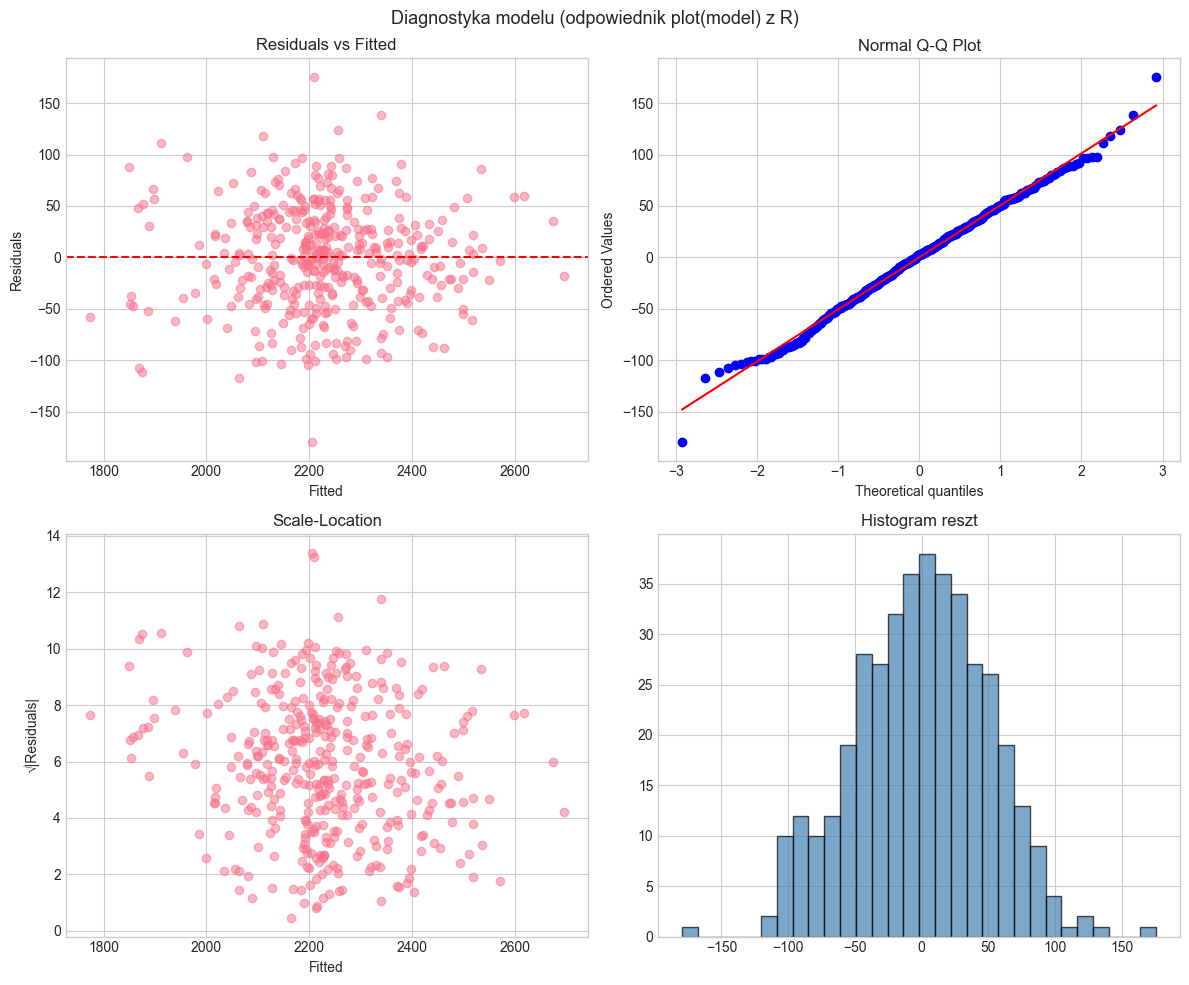

In [24]:
# Wykresy diagnostyczne (odpowiednik plot(model) z R)
r = model_t.resid
fitted = model_t.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(fitted, r, alpha=0.5)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Residuals vs Fitted'); axes[0, 0].set_xlabel('Fitted'); axes[0, 0].set_ylabel('Residuals')

# 2. Q-Q plot (normalność reszt)
stats.probplot(r, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q Plot')

# 3. Scale-Location (heteroskedastyczność)
axes[1, 0].scatter(fitted, np.sqrt(np.abs(r)), alpha=0.5)
axes[1, 0].set_title('Scale-Location'); axes[1, 0].set_xlabel('Fitted'); axes[1, 0].set_ylabel('√|Residuals|')

# 4. Histogram reszt
axes[1, 1].hist(r, bins=30, edgecolor='k', color='steelblue', alpha=0.7)
axes[1, 1].set_title('Histogram reszt')

plt.suptitle('Diagnostyka modelu (odpowiednik plot(model) z R)', fontsize=13)
plt.tight_layout(); plt.show()

---

### Zadanie 2

$$F = \frac{(SSE_c - (SSE_1 + SSE_2)) / k}{(SSE_1 + SSE_2) / (n_1 + n_2 - 2k)}$$

**Test Chow** - sprawdzamy, czy jedna prosta regresji pasuje do całego zbioru, czy powinniśmy mieć dwie osobne.

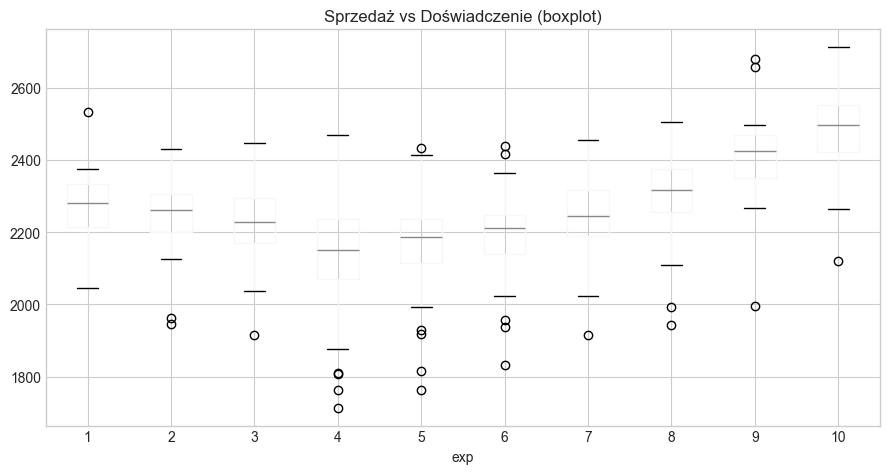

Statystyka F Chow: 0.951
P-Value:           0.4861
Przerwa strukturalna: NIE


In [25]:
# === PRZERWY STRUKTURALNE - Test Chow

fig, ax = plt.subplots(figsize=(9, 5))
data.boxplot(column='sales', by='exp', ax=ax)
ax.set_title('Sprzedaż vs Doświadczenie (boxplot)'); plt.suptitle('')
plt.tight_layout(); plt.show()

# ZADANIE:
# 1. Dzielimy na dwie grupy
# 2. Liczymy modele
# 3. Bierzemy sumy kwadratów błędów (SSE)
# 4. Liczymy statystykę z wzoru testu Chow
# 5. Znajdujemy p-value

formula = 'sales ~ temp*weekend + rain + beach + other + price + exp_sq + flavors_sq'

med = data['exp'].median()
g1 = data[data['exp'] < med].copy()
g2 = data[data['exp'] >= med].copy()

model_c = smf.ols(formula, data=data).fit()
model1  = smf.ols(formula, data=g1).fit()
model2  = smf.ols(formula, data=g2).fit()

sse  = (model_c.resid**2).sum()
sse1 = (model1.resid**2).sum()
sse2 = (model2.resid**2).sum()

k  = len(model_c.params)
n1 = len(g1); n2 = len(g2)

F_stat = ((sse - (sse1 + sse2)) / k) / ((sse1 + sse2) / (n1 + n2 - 2*k))
p_val  = 1 - f_dist.cdf(F_stat, k, n1 + n2 - 2*k)

print(f'Statystyka F Chow: {F_stat:.3f}')
print(f'P-Value:           {p_val:.4f}')
print(f'Przerwa strukturalna: {"TAK (p < 0.05)" if p_val < 0.05 else "NIE"}')

In [26]:
# Poprawna funkcja chow_test
def chow_test(formula, d1, d2):
    """Test Chow na przerwy strukturalne."""
    d = pd.concat([d1, d2], ignore_index=True)
    mC = smf.ols(formula, data=d).fit()
    Sc = (mC.resid**2).sum()
    
    m1 = smf.ols(formula, data=d1).fit()
    S1 = (m1.resid**2).sum()
    
    m2 = smf.ols(formula, data=d2).fit()
    S2 = (m2.resid**2).sum()
    
    k_params = len(mC.params)
    stat  = ((Sc - S1 - S2) / k_params) / ((S1 + S2) / (len(d) - 2*k_params))
    p_val = 1 - f_dist.cdf(stat, k_params, len(d) - 2*k_params)
    
    print(f'Statystyka: {round(stat, 3)}')
    print(f'P-Value:    {round(p_val, 3)}')
    return stat, p_val

chow_test(formula, g1, g2)

Statystyka: 0.951
P-Value:    0.486


(np.float64(0.9510811203948452), np.float64(0.4861171085108784))

---

### Zadanie 3

In [27]:
# Używamy test_summary zdefiniowanego w Zadaniu 1
model_t = smf.ols('sales ~ temp*weekend + beach + rain + other + price + exp_sq + flavors_sq', data=data).fit()
test_summary(model_t)

model = smf.ols('sales ~ temp*weekend + rain + beach + other + price + exp + flavors', data=data).fit()
print(model.summary())
test_summary(model)

DIAGNOSTYKA MODELU

VIF (współliniowość, > 5 = problem):
  temp: 1.258
  weekend: 96.420 *** PROBLEM
  temp:weekend: 94.759 *** PROBLEM
  beach: 3.832
  rain: 1.146
  other: 4.012
  price: 1.244
  exp_sq: 1.280
  flavors_sq: 1.584

Shapiro-Wilk (normalność reszt):
  W=0.9952, p=0.2476  ✓ ok

Breusch-Pagan (heteroskedastyczność):
  p=0.4306  ✓ homoskedastyczność

RESET (postać liniowa):
  p=0.6777  ✓ ok

Test serii (autokorelacja):
  p=0.5313  ✓ losowość ok

Durbin-Watson: 2.0986  (idealnie ~2.0)
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     129.2
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          3.37e-111
Time:                        22:48:19   Log-Likelihood:                -2297.1
No. Observations:        

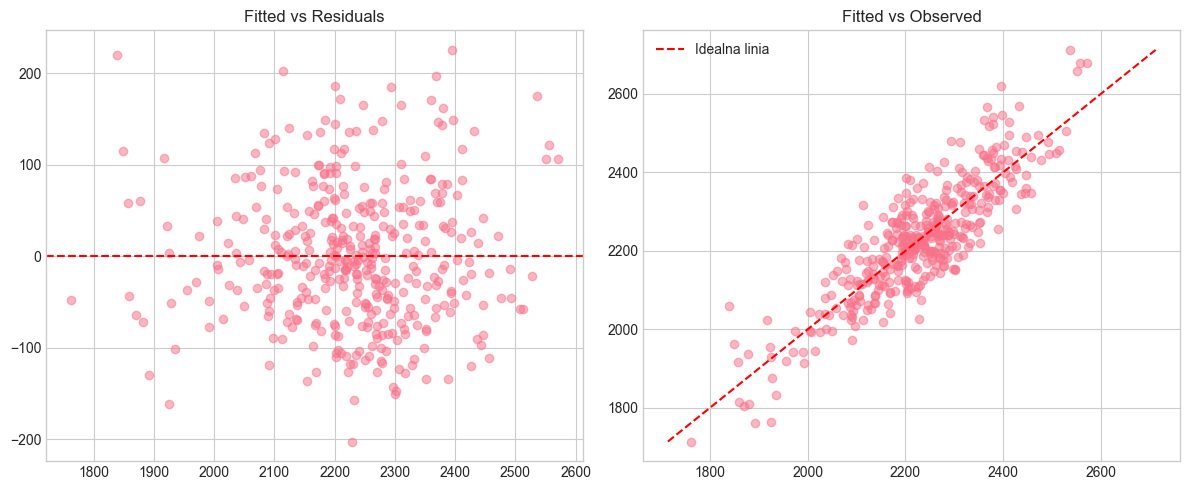

In [28]:
# Wykresy fitted vs residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(model.fittedvalues, model.resid, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Fitted vs Residuals')

axes[1].scatter(model.fittedvalues, data.loc[model.model.data.row_labels, 'sales'], alpha=0.5)
lim = [data['sales'].min(), data['sales'].max()]
axes[1].plot(lim, lim, color='red', linestyle='--', label='Idealna linia')
axes[1].legend()
axes[1].set_title('Fitted vs Observed')
plt.tight_layout(); plt.show()

---

## Laboratoria 4

---

### Zadanie 1

Skupiamy się na: złej postaci funkcyjnej oraz heteroskedastyczności.

In [29]:
# DIAGNOZOWANIE

model = smf.ols('sales ~ weekend + beach + rain + exp + temp + flavors', data=data).fit()
test_summary(model)
# Trzy testy wskazują na brak losowości, heteroskedastyczność i złą postać

# Dodajemy mniej znaczącą zmienną by poprawić model
model = smf.ols('sales ~ weekend + beach + rain + exp + temp + flavors + parking', data=data).fit()
test_summary(model)

DIAGNOSTYKA MODELU

VIF (współliniowość, > 5 = problem):
  weekend: 1.067
  beach: 1.024
  rain: 1.006
  exp: 1.018
  temp: 1.073
  flavors: 1.039

Shapiro-Wilk (normalność reszt):
  W=0.9830, p=0.0001  ✗ brak normalności

Breusch-Pagan (heteroskedastyczność):
  p=0.0038  ✗ heteroskedastyczność!

RESET (postać liniowa):
  p=0.0112  ✗ zła postać modelu!

Test serii (autokorelacja):
  p=0.0090  ✗ autokorelacja!

Durbin-Watson: 1.8140  (idealnie ~2.0)
DIAGNOSTYKA MODELU

VIF (współliniowość, > 5 = problem):
  weekend: 1.067
  beach: 1.078
  rain: 1.006
  exp: 1.018
  temp: 1.073
  flavors: 1.177
  parking: 1.167

Shapiro-Wilk (normalność reszt):
  W=0.9837, p=0.0002  ✗ brak normalności

Breusch-Pagan (heteroskedastyczność):
  p=0.0121  ✗ heteroskedastyczność!

RESET (postać liniowa):
  p=0.0088  ✗ zła postać modelu!

Test serii (autokorelacja):
  p=0.0095  ✗ autokorelacja!

Durbin-Watson: 1.8450  (idealnie ~2.0)


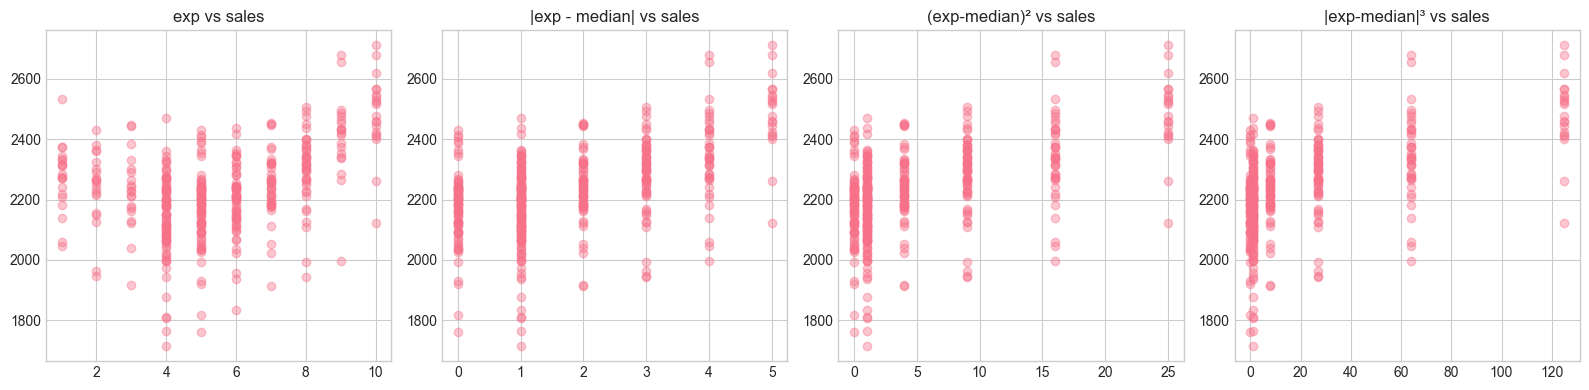

In [30]:
# Nieliniowe zależności
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
exp_med = data['exp'].median()

axes[0].scatter(data['exp'], data['sales'], alpha=0.4)
axes[0].set_title('exp vs sales')

axes[1].scatter(abs(data['exp'] - exp_med), data['sales'], alpha=0.4)
axes[1].set_title('|exp - median| vs sales')

axes[2].scatter((data['exp'] - exp_med)**2, data['sales'], alpha=0.4)
axes[2].set_title('(exp-median)² vs sales')

axes[3].scatter(abs(data['exp'] - exp_med)**3, data['sales'], alpha=0.4)
axes[3].set_title('|exp-median|³ vs sales')

plt.tight_layout(); plt.show()

In [31]:
# Poprawiony model z przekształceniem wielomianowym
data['exp_poly2'] = (abs(data['exp'] - data['exp'].median()))**2
model = smf.ols('sales ~ weekend + beach + rain + exp_poly2 + temp + flavors + parking', data=data).fit()
test_summary(model)  # poprawiony model

DIAGNOSTYKA MODELU

VIF (współliniowość, > 5 = problem):
  weekend: 1.067
  beach: 1.104
  rain: 1.006
  exp_poly2: 1.028
  temp: 1.073
  flavors: 1.160
  parking: 1.167

Shapiro-Wilk (normalność reszt):
  W=0.9917, p=0.0239  ✗ brak normalności

Breusch-Pagan (heteroskedastyczność):
  p=0.0016  ✗ heteroskedastyczność!

RESET (postać liniowa):
  p=0.8455  ✓ ok

Test serii (autokorelacja):
  p=0.3573  ✓ losowość ok

Durbin-Watson: 2.1514  (idealnie ~2.0)


**Odporne błędy standardowe** (HC - Heteroskedasticity-Consistent)

Użycie `cov_type='HC3'` to sposób na "naprawienie" wyników bez zmiany samego modelu.

In [32]:
# Odporne błędy standardowe - odpowiednik vcovHC + coeftest z R
model = smf.ols('sales ~ weekend + beach + rain + exp + temp + flavors', data=data).fit()
print('=== Standardowe błędy ===')
print(model.summary().tables[1])

model_hc = model.get_robustcov_results(cov_type='HC3')
print('\n=== Odporne błędy (HC3) ===')
print(model_hc.summary().tables[1])

=== Standardowe błędy ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1876.5130     40.500     46.334      0.000    1796.889    1956.137
weekend      156.4188     11.366     13.763      0.000     134.074     178.764
beach         -0.1435      0.016     -8.825      0.000      -0.175      -0.112
rain         -40.2303      1.673    -24.053      0.000     -43.519     -36.942
exp           26.5204      1.782     14.883      0.000      23.017      30.024
temp          11.3841      1.368      8.322      0.000       8.695      14.073
flavors       -1.5212      2.518     -0.604      0.546      -6.472       3.429

=== Odporne błędy (HC3) ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1876.5130     41.123     45.632      0.000    1795.664    1957.3

**Regresja ważona (WLS)**

Dajemy większą wagę obserwacjom z małą wariancją błędu, a mniejszą tym z dużą.

In [33]:
# Regresja ważona - ostatnia metoda na heteroskedastyczność
data['e_sq'] = model.resid**2  # wariancja reszt

me = smf.ols('e_sq ~ weekend + beach + rain + exp + temp + flavors', data=data).fit()
data['w'] = me.fittedvalues
data['w'] = data['w'].clip(lower=1e-6)  # bezpieczeństwo: brak ujemnych wag

model_wls = smf.wls(
    'sales ~ weekend + beach + rain + exp + temp + flavors',
    data=data,
    weights=1/data['w']
).fit()

test_summary(model_wls)  # pozbywamy się heteroskedastyczności

DIAGNOSTYKA MODELU

VIF (współliniowość, > 5 = problem):
  weekend: 1.067
  beach: 1.024
  rain: 1.006
  exp: 1.018
  temp: 1.073
  flavors: 1.039

Shapiro-Wilk (normalność reszt):
  W=0.9780, p=0.0000  ✗ brak normalności

Breusch-Pagan (heteroskedastyczność):
  p=0.0000  ✗ heteroskedastyczność!

RESET (postać liniowa):
  p=0.0018  ✗ zła postać modelu!

Test serii (autokorelacja):
  p=0.0081  ✗ autokorelacja!

Durbin-Watson: 1.8782  (idealnie ~2.0)


---

### Zadanie 2

**PROGNOZOWANIE**

In [34]:
model = smf.ols(
    'sales ~ weekend + beach + rain + exp_poly2 + temp + flavors + parking',
    data=data
).fit()

# Prognoza dla nowej obserwacji
new_obs = pd.DataFrame({
    'weekend': [0], 'beach': [300], 'rain': [0],
    'exp_poly2': [(abs(0 - data['exp'].median()))**2],
    'temp': [20], 'flavors': [5], 'parking': [0]
})

p = model.get_prediction(new_obs)
pred_summary = p.summary_frame(alpha=0.01)  # 99% przedział ufności
print('=== Prognoza ===')
print(pred_summary[['mean', 'mean_se', 'obs_ci_lower', 'obs_ci_upper']])

fit_val = pred_summary['mean'].values[0]
se_val  = pred_summary['mean_se'].values[0]
z = norm.ppf(0.995)  # 99%
l = fit_val - se_val * z
u = fit_val + se_val * z
print(f'\nRęczny 99% PI: [{l:.2f}, {u:.2f}]')

=== Prognoza ===
          mean    mean_se  obs_ci_lower  obs_ci_upper
0  2422.783379  11.839389    2267.20575   2578.361008

Ręczny 99% PI: [2392.29, 2453.28]


**MAE** - Średni błąd bezwzględny  
**RMSE** - Pierwiastek błędu średniokwadratowego  
**MAPE** - Średni procentowy błąd bezwzględny

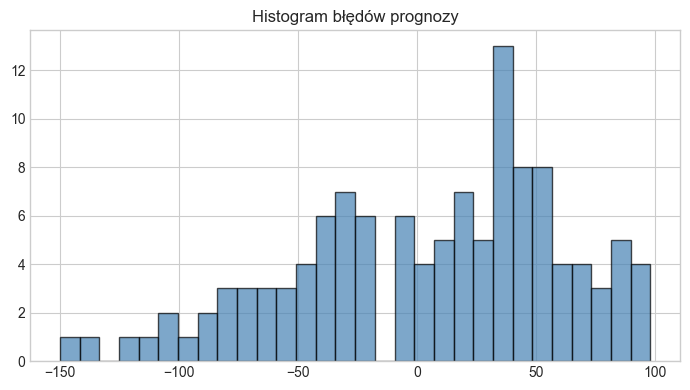

MAE:  47.47
RMSE: 56.46
MAPE: 2.13%


In [35]:
# Błędy ex post - sprawdzamy model na danych historycznych
from sklearn.model_selection import KFold

np.random.seed(333)
idx = np.random.permutation(len(data))
data_r = data.iloc[idx].reset_index(drop=True)

train = data_r.iloc[:280].copy()
test  = data_r.iloc[280:].copy()

# Przelicz exp_poly2 na podstawie mediany treningu
exp_med_train = train['exp'].median()
train['exp_poly2'] = (abs(train['exp'] - exp_med_train))**2
test['exp_poly2']  = (abs(test['exp']  - exp_med_train))**2

model = smf.ols(
    'sales ~ weekend + beach + rain + exp_poly2 + temp + flavors + parking',
    data=train
).fit()

p_fit = model.predict(test)
e = test['sales'] - p_fit

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(e, bins=30, edgecolor='k', color='steelblue', alpha=0.7)
ax.set_title('Histogram błędów prognozy')
plt.tight_layout(); plt.show()

MAE  = np.mean(np.abs(e))
RMSE = np.sqrt(np.mean(e**2))
MAPE = np.mean(np.abs(e / test['sales'])) * 100

print(f'MAE:  {MAE:.2f}')
print(f'RMSE: {RMSE:.2f}')
print(f'MAPE: {MAPE:.2f}%')

In [36]:
# ZADANIE: k-krotna walidacja krzyżowa (k-fold CV)
# Odpowiednik pętli for i=1:10 z R

np.random.seed(333)
idx = np.random.permutation(len(data))
data_r = data.iloc[idx].reset_index(drop=True)

errors = []
kf = KFold(n_splits=10, shuffle=False)

for train_idx, test_idx in kf.split(data_r):
    tr = data_r.iloc[train_idx].copy()
    te = data_r.iloc[test_idx].copy()
    
    exp_med_tr = tr['exp'].median()
    tr['exp_poly2'] = (abs(tr['exp'] - exp_med_tr))**2
    te['exp_poly2'] = (abs(te['exp'] - exp_med_tr))**2
    
    m = smf.ols(
        'sales ~ weekend + beach + rain + exp_poly2 + temp + flavors + parking',
        data=tr
    ).fit()
    
    p_fit = m.predict(te)
    e_fold = te['sales'] - p_fit
    
    errors.append({
        'MAE':  np.mean(np.abs(e_fold)),
        'RMSE': np.sqrt(np.mean(e_fold**2)),
        'MAPE': np.mean(np.abs(e_fold / te['sales'])) * 100
    })

errors_df = pd.DataFrame(errors)
print(errors_df.round(2))
print(f'\nŚredni MAPE (10-fold CV): {errors_df["MAPE"].mean():.2f}%')

     MAE   RMSE  MAPE
0  53.64  70.54  2.40
1  52.51  64.69  2.37
2  54.61  61.61  2.45
3  40.37  55.88  1.82
4  48.55  61.52  2.26
5  42.52  55.12  1.96
6  49.75  59.32  2.22
7  45.76  54.29  2.06
8  46.39  54.62  2.07
9  48.28  58.71  2.20

Średni MAPE (10-fold CV): 2.18%


---

## Laboratoria 5

---

### Zadanie 1

Modele zmiennej dychotomicznej (0-1)

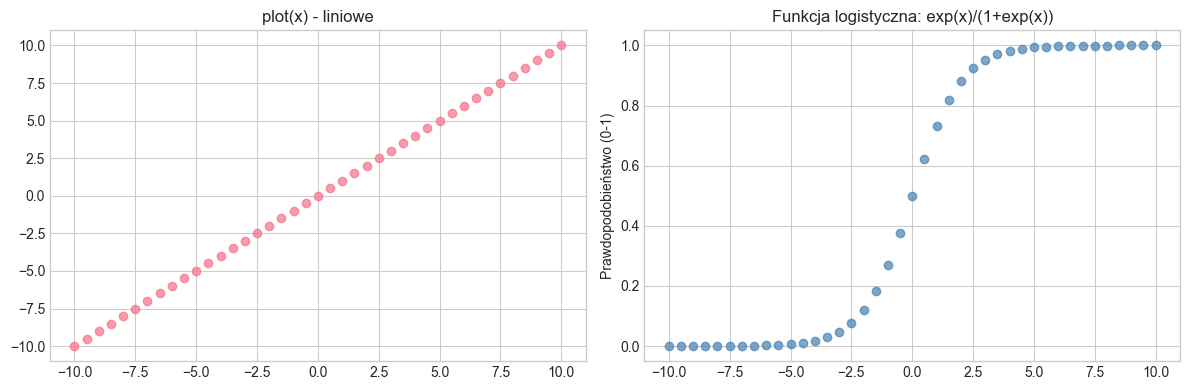

In [37]:
# Przypadek 1 - y jest zmienną kategoryczną (0/1)

x = np.arange(-10, 10.5, 0.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(x, x, alpha=0.7)
axes[0].set_title('plot(x) - liniowe')

logistic = np.exp(x) / (1 + np.exp(x))
axes[1].scatter(x, logistic, color='steelblue', alpha=0.7)
axes[1].set_title('Funkcja logistyczna: exp(x)/(1+exp(x))')
axes[1].set_ylabel('Prawdopodobieństwo (0-1)')
plt.tight_layout(); plt.show()

         Survived      Pclass         Age       SibSp       Parch        Fare
count  712.000000  712.000000  712.000000  712.000000  712.000000  712.000000
mean     0.404494    2.240169   29.642093    0.514045    0.432584   34.567251
std      0.491139    0.836854   14.492933    0.930692    0.854181   52.938648
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    1.000000   20.000000    0.000000    0.000000    8.050000
50%      0.000000    2.000000   28.000000    0.000000    0.000000   15.645850
75%      1.000000    3.000000   38.000000    1.000000    1.000000   33.000000
max      1.000000    3.000000   80.000000    5.000000    6.000000  512.329200


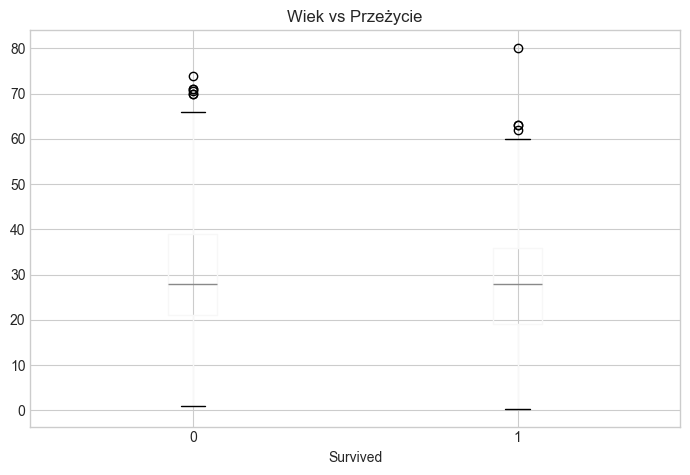

In [38]:
# TITANIC.CSV
# Jeśli nie masz pliku lokalnie, pobierz z seabornem:
titanic = sns.load_dataset('titanic')[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
titanic = titanic.rename(columns={'survived': 'Survived', 'pclass': 'Pclass', 'sex': 'Sex',
                                   'age': 'Age', 'sibsp': 'SibSp', 'parch': 'Parch',
                                   'fare': 'Fare', 'embarked': 'Embarked'})
titanic = titanic.dropna()

print(titanic.describe())

titanic['Pclass']   = titanic['Pclass'].astype('category')
titanic['Sex']      = titanic['Sex'].astype('category')
titanic['Embarked'] = titanic['Embarked'].astype('category')

# Boxplot: wiek vs przeżycie
fig, ax = plt.subplots(figsize=(7, 5))
titanic.boxplot(column='Age', by='Survived', ax=ax)
ax.set_title('Wiek vs Przeżycie'); plt.suptitle('')
plt.tight_layout(); plt.show()

Interpretacja przez iloraz szans (Odds Ratio):

- Jeśli $\exp(\beta) > 1$: szansa na $Y=1$ rośnie.
- Jeśli $\exp(\beta) < 1$: szansa na $Y=1$ maleje.

Optimization terminated successfully.
         Current function value: 0.446117
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  712
Model:                          Logit   Df Residuals:                      704
Method:                           MLE   Df Model:                            7
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                  0.3389
Time:                        22:48:26   Log-Likelihood:                -317.64
converged:                       True   LL-Null:                       -480.45
Covariance Type:            nonrobust   LLR p-value:                 2.014e-66
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.1720      0.503      8.289      0.000       3.185       5.159
C(Pclass)[T.2]   

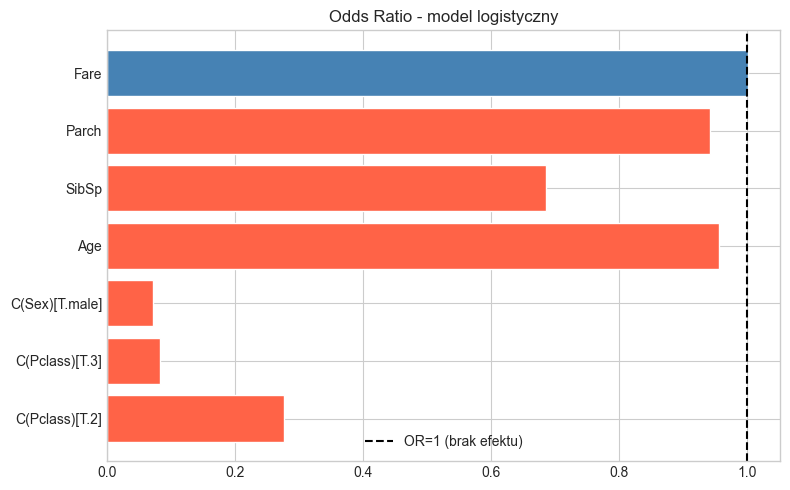

In [39]:
# glm z family=binomial w R = logit w Pythonie
model_logit = smf.logit(
    'Survived ~ C(Pclass) + C(Sex) + Age + SibSp + Parch + Fare',
    data=titanic
).fit()
print(model_logit.summary())

# Odds Ratio
print('\n=== Odds Ratio (exp(coef)) ===')
or_df = np.exp(model_logit.params).rename('Odds Ratio')
print(or_df)

# Zmiana procentowa: (exp(beta) - 1) * 100
pclass2_coef = model_logit.params.get('C(Pclass)[T.2]', model_logit.params.iloc[1])
print(f'\nKlasa 2 vs 1: {(np.exp(pclass2_coef)-1)*100:.1f}%')

age_coef = model_logit.params['Age']
print(f'Age: {(np.exp(age_coef)-1)*100:.2f}% (zmiana szansy na przeżycie o 1 rok starszej osoby)')

# BONUS: wizualizacja OR
fig, ax = plt.subplots(figsize=(8, 5))
or_df_plot = or_df.drop('Intercept', errors='ignore')
colors = ['tomato' if v < 1 else 'steelblue' for v in or_df_plot]
ax.barh(or_df_plot.index, or_df_plot.values, color=colors)
ax.axvline(1, color='k', linestyle='--', label='OR=1 (brak efektu)')
ax.set_title('Odds Ratio - model logistyczny'); ax.legend()
plt.tight_layout(); plt.show()

---

### Zadanie 2

**Kryterium AIC (Akaike Information Criterion)** - kara za skomplikowanie modelu

In [40]:
np.random.seed(123)
from sklearn.model_selection import train_test_split

train_t, test_t = train_test_split(titanic, test_size=0.3, random_state=123)

model = smf.logit(
    'Survived ~ C(Pclass) + C(Sex) + Age + SibSp + Fare',
    data=train_t
).fit()
print(model.summary())
print(f'\nAIC: {model.aic:.2f}')

# Usuwamy nieistotne zmienne
model2 = smf.logit(
    'Survived ~ C(Pclass) + C(Sex) + Age + SibSp',
    data=train_t
).fit()
print(f'AIC (model uproszczony): {model2.aic:.2f}')
print('Mniejsze AIC = lepszy model!')

# Prognoza
p_prob = model2.predict(test_t)
p = (p_prob > 0.5).astype(int)

Optimization terminated successfully.
         Current function value: 0.435496
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  498
Model:                          Logit   Df Residuals:                      491
Method:                           MLE   Df Model:                            6
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                  0.3528
Time:                        22:48:26   Log-Likelihood:                -216.88
converged:                       True   LL-Null:                       -335.08
Covariance Type:            nonrobust   LLR p-value:                 3.290e-48
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.1202      0.608      6.779      0.000       2.929       5.311
C(Pclass)[T.2]   

---

### Zadanie 3

**Tablica pomyłek (Confusion Matrix)**

- **ACC** accuracy - odsetek poprawnych odpowiedzi
- **PPV** precision - jaki odsetek predykowanych jedynek jest faktycznie jedynką
- **TPR** sensitivity (czułość)
- **TNR** specificity (swoistość)

Liczba predykowanych 1: 71

Tablica pomyłek:
               Predykowane 0  Predykowane 1
Rzeczywiste 0            112             13
Rzeczywiste 1             31             58

Accuracy:    0.7944
Sensitivity: 0.6517
Specificity: 0.8960
Precision:   0.8169


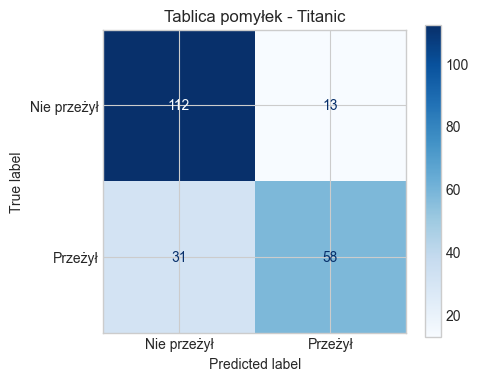


=== Raport klasyfikacji ===
              precision    recall  f1-score   support

 Nie przeżył       0.78      0.90      0.84       125
     Przeżył       0.82      0.65      0.72        89

    accuracy                           0.79       214
   macro avg       0.80      0.77      0.78       214
weighted avg       0.80      0.79      0.79       214



In [41]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print(f'Liczba predykowanych 1: {p.sum()}')

# Tablica pomyłek
cm = confusion_matrix(test_t['Survived'], p)
print('\nTablica pomyłek:')
print(pd.DataFrame(cm, index=['Rzeczywiste 0', 'Rzeczywiste 1'],
                      columns=['Predykowane 0', 'Predykowane 1']))

# Miary jakości
accuracy    = (cm[0, 0] + cm[1, 1]) / cm.sum()
sensitivity = cm[1, 1] / cm[1, :].sum()  # TPR
specificity = cm[0, 0] / cm[0, :].sum()  # TNR
precision   = cm[1, 1] / cm[:, 1].sum()  # PPV

print(f'\nAccuracy:    {accuracy:.4f}')
print(f'Sensitivity: {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')
print(f'Precision:   {precision:.4f}')

# Wizualizacja
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Nie przeżył', 'Przeżył']).plot(ax=ax, cmap='Blues')
ax.set_title('Tablica pomyłek - Titanic')
plt.tight_layout(); plt.show()

print('\n=== Raport klasyfikacji ===')
print(classification_report(test_t['Survived'], p, target_names=['Nie przeżył', 'Przeżył']))

---

### Zadanie 4

**Funkcja produkcji Cobba-Douglasa**

$$y = a \cdot K^b \cdot L^c$$

Linearyzacja logarytmiczna:

$$\log(y) = \log(a) + b \cdot \log(K) + c \cdot \log(L)$$

In [42]:
# Funkcja produkcji Cobba-Douglasa
# Jeśli nie masz pliku lokalnie, tworzymy przykładowe dane:

np.random.seed(42)
n = 100
K = np.random.lognormal(5, 0.5, n)   # inwestycje/kapital
L = np.random.lognormal(3, 0.3, n)   # nakłady pracy
a_true, b_true, c_true = 2.55, 0.94, 0.06
prod_data = pd.DataFrame({
    'output':      a_true * K**b_true * L**c_true * np.exp(np.random.normal(0, 0.1, n)),
    'investments': K,
    'employees':   L
})

# Regresja po zlogarytmowaniu (linearyzacja)
prod_data['log_output']  = np.log(prod_data['output'])
prod_data['log_K']       = np.log(prod_data['investments'])
prod_data['log_L']       = np.log(prod_data['employees'])

model_cd = smf.ols('log_output ~ log_K + log_L', data=prod_data).fit()
print(model_cd.summary())

a_est = np.exp(model_cd.params['Intercept'])
b_est = model_cd.params['log_K']
c_est = model_cd.params['log_L']
print(f'\nEstymowana funkcja: y = {a_est:.3f} * K^{b_est:.3f} * L^{c_est:.3f}')
print(f'Suma elastyczności (b+c): {b_est + c_est:.4f}')
print(f'Interpretacja: 1% wzrost kapitału -> ~{b_est:.1%} wzrost produkcji')
print(f'               1% wzrost pracy    -> ~{c_est:.1%} wzrost produkcji')

                            OLS Regression Results                            
Dep. Variable:             log_output   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     849.7
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           3.31e-62
Time:                        22:48:26   Log-Likelihood:                 82.636
No. Observations:                 100   AIC:                            -159.3
Df Residuals:                      97   BIC:                            -151.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7311      0.176      4.146      0.0

**Efekty skali** - "Co się stanie z produkcją, jeśli podwoimy wszystkie nakłady?"

- $b + c = 1$: Stałe efekty skali
- $b + c > 1$: Rosnące efekty skali
- $b + c < 1$: Malejące efekty skali

In [43]:
# Efekty skali - odpowiednik linearHypothesis z R
from statsmodels.stats.contrast import ContrastResults

def linear_hypothesis_test(model, R_matrix, r_vector, hypothesis_name=""):
    """
    Test liniowej hipotezy: R*beta = r
    Odpowiednik linearHypothesis() z pakietu car w R.
    """
    params = model.params.values
    cov    = model.cov_params().values
    R = np.array(R_matrix)
    r = np.array(r_vector)
    
    diff   = R @ params - r
    se_mat = R @ cov @ R.T
    chi2   = float(diff @ np.linalg.inv(se_mat) @ diff)
    df     = R.shape[0]
    p_val  = 1 - stats.chi2.cdf(chi2, df)
    
    print(f'=== {hypothesis_name} ===')
    print(f'Chi² = {chi2:.4f}, df = {df}, p-value = {p_val:.4f}')
    print(f'Interpretacja: {"Nie odrzucamy H0" if p_val > 0.05 else "Odrzucamy H0"}')
    return chi2, p_val

# H0: b + c = 1 (stałe efekty skali)
# params: [Intercept, log_K, log_L] -> indeksy [0, 1, 2]
R_scale = [[0, 1, 1]]   # b + c
r_scale = [1]            # = 1

linear_hypothesis_test(
    model_cd, R_scale, r_scale,
    "b + c = 1 (stałe efekty skali)"
)

# H0: c = 0.05
R_c = [[0, 0, 1]]
r_c = [0.05]
linear_hypothesis_test(
    model_cd, R_c, r_c,
    "c (log_L) = 0.05"
)

=== b + c = 1 (stałe efekty skali) ===
Chi² = 0.7416, df = 1, p-value = 0.3892
Interpretacja: Nie odrzucamy H0
=== c (log_L) = 0.05 ===
Chi² = 0.0240, df = 1, p-value = 0.8769
Interpretacja: Nie odrzucamy H0


(0.024008894797879703, np.float64(0.8768622812844562))

---

## Laboratoria 6

---

### Zadanie 1

**Szeregi Czasowe**

- **Stacjonarność**: Średnia i wariancja szeregu nie zmieniają się w czasie.
- **Różnicowanie (diff)**: $y_t - y_{t-1}$ — usuwa trend.

In [44]:
# Generujemy przykładowe dane czasowe (jeśli nie ma pliku)
np.random.seed(42)
n_weeks = 150
weeks   = np.arange(1, n_weeks + 1)

# Dane z trendem, sezonowością i autokorelacją
trend     = 0.5 * weeks
seasonal  = 20 * np.sin(2 * np.pi * weeks / 52)
ar_noise  = np.zeros(n_weeks)
ar_noise[0] = np.random.normal(0, 10)
for t in range(1, n_weeks):
    ar_noise[t] = 0.7 * ar_noise[t-1] + np.random.normal(0, 10)

ts_data = pd.DataFrame({
    'week':             weeks,
    'sales':            500 + trend + seasonal + ar_noise,
    'price':            np.random.normal(10, 1, n_weeks),
    'promo':            np.random.choice([0, 0.1, 0.2], n_weeks),
    'is_holiday_week':  (weeks % 52 >= 48).astype(int),
    'is_winter':        ((weeks % 52 >= 45) | (weeks % 52 <= 8)).astype(int)
})

train_ts = ts_data.iloc[:120].copy()
test_ts  = ts_data.iloc[120:].copy()

model_ts = smf.ols('sales ~ price + promo + is_holiday_week + is_winter', data=train_ts).fit()
print(model_ts.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.8730
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.483
Time:                        22:48:26   Log-Likelihood:                -567.22
No. Observations:                 120   AIC:                             1144.
Df Residuals:                     115   BIC:                             1158.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         549.0014     24.828     

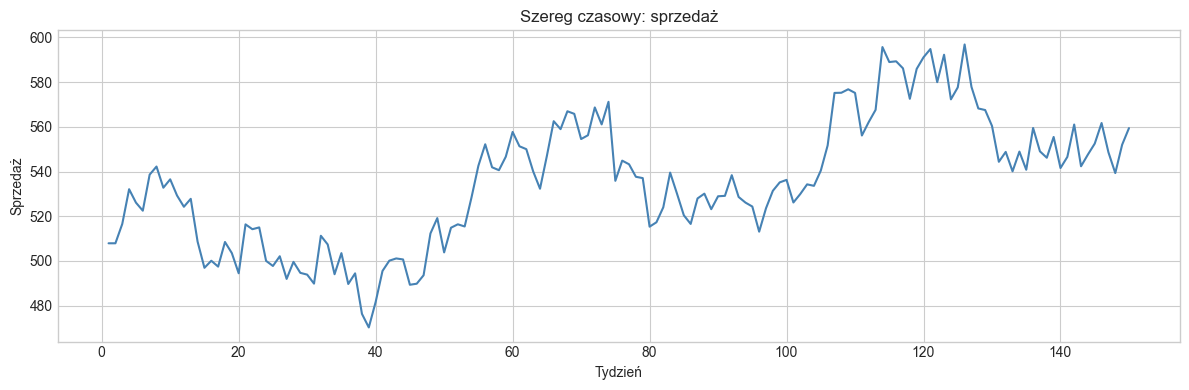

Durbin-Watson: 0.1776
Chcemy wyniku bliskiego 2. Jeśli ~0 -> dodatnia autokorelacja.


In [45]:
# Autokorelacja - wykres szeregu czasowego
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts_data['week'], ts_data['sales'], color='steelblue')
ax.set_title('Szereg czasowy: sprzedaż'); ax.set_xlabel('Tydzień'); ax.set_ylabel('Sprzedaż')
plt.tight_layout(); plt.show()

# Test Durbina-Watsona
dw = durbin_watson(model_ts.resid)
print(f'Durbin-Watson: {dw:.4f}')
print('Chcemy wyniku bliskiego 2. Jeśli ~0 -> dodatnia autokorelacja.')

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.8730
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.483
Time:                        22:51:43   Log-Likelihood:                -567.22
No. Observations:                 120   AIC:                             1144.
Df Residuals:                     115   BIC:                             1158.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         549.0014     24.828     

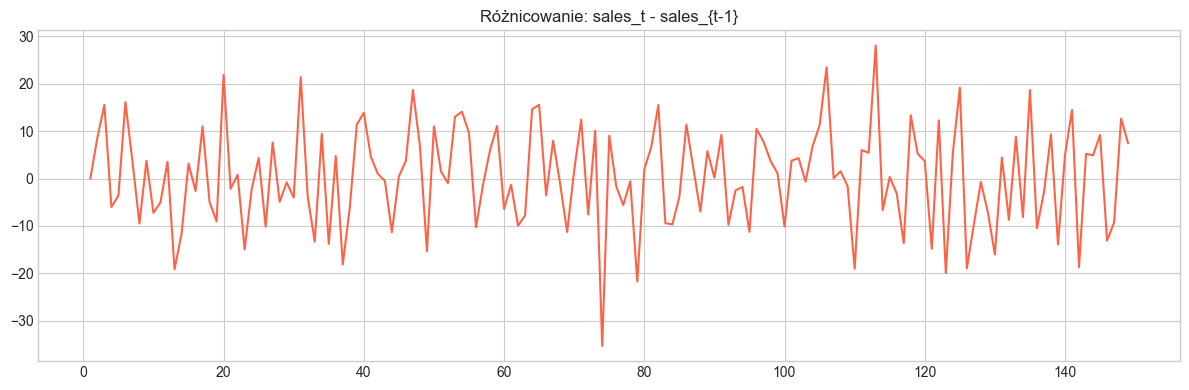

ADF (sales):         p=0.2847  -> NIEstacjonarny
ADF (diff(sales)):   p=0.0000  -> stacjonarny


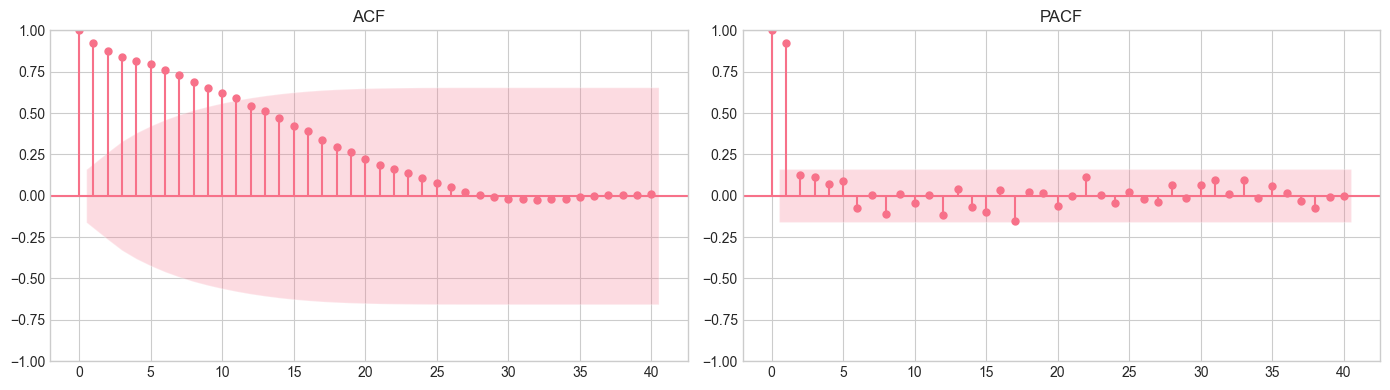

Nasze dane są skorelowane do ~3 okresów wstecz (słupki poza niebieskimi liniami)


In [47]:
# Stacjonarność i różnicowanie
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Dodajemy zmienną trend
ts_data['week_nr'] = ts_data['week']
train_ts['week_nr'] = train_ts['week']
test_ts['week_nr']  = test_ts['week']

model_ts2 = smf.ols('sales ~ price + promo + is_holiday_week + is_winter', data=train_ts).fit()
print(model_ts2.summary())
print(f'DW: {durbin_watson(model_ts2.resid):.4f}')

# Autoregresja
train_ts['sales_lag'] = train_ts['sales'].shift(1)
model_ts3 = smf.ols('sales ~ week_nr + price + promo + is_holiday_week + is_winter + sales_lag', data=train_ts).fit()
print(f'DW po lag: {durbin_watson(model_ts3.resid):.4f}')

# Różnicowanie - usuwa trend
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts_data['sales'].diff().dropna(), color='tomato')
ax.set_title('Różnicowanie: sales_t - sales_{t-1}')
plt.tight_layout(); plt.show()

# Test ADF na stacjonarność
adf_raw   = adfuller(ts_data['sales'])
adf_diff  = adfuller(ts_data['sales'].diff().dropna())
print(f'ADF (sales):         p={adf_raw[1]:.4f}  -> {"stacjonarny" if adf_raw[1] < 0.05 else "NIEstacjonarny"}')
print(f'ADF (diff(sales)):   p={adf_diff[1]:.4f}  -> {"stacjonarny" if adf_diff[1] < 0.05 else "NIEstacjonarny"}')

# Wykres PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts_data['sales'], lags=40, ax=axes[0]); axes[0].set_title('ACF')
plot_pacf(ts_data['sales'], lags=40, ax=axes[1]); axes[1].set_title('PACF')
plt.tight_layout(); plt.show()
print('Nasze dane są skorelowane do ~3 okresów wstecz (słupki poza niebieskimi liniami)')

`ARIMA(p, d, q)`:
- **p** (AR): Liczba opóźnień z PACF
- **d** (I): Ile razy różnicowano
- **q** (MA): Liczba poprzednich błędów prognozy

In [48]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

# AR(3)
model_ar3 = ARIMA(train_ts['sales'], order=(3, 0, 0)).fit()
print(model_ar3.summary())
print(f'AIC: {model_ar3.aic:.2f}  (im mniejsze, tym lepiej)')

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  120
Model:                 ARIMA(3, 0, 0)   Log Likelihood                -449.091
Date:                Tue, 14 Apr 2026   AIC                            908.181
Time:                        22:51:52   BIC                            922.119
Sample:                             0   HQIC                           913.841
                                - 120                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        534.6700     17.426     30.682      0.000     500.516     568.824
ar.L1          0.8885      0.110      8.113      0.000       0.674       1.103
ar.L2         -0.0061      0.153     -0.040      0.9

Zainstaluj pmdarima: pip install pmdarima
Alternatywnie używamy ręcznego ARIMA(3,0,0):
      lb_stat  lb_pvalue
10  10.441044   0.402687
MAE: 9.82


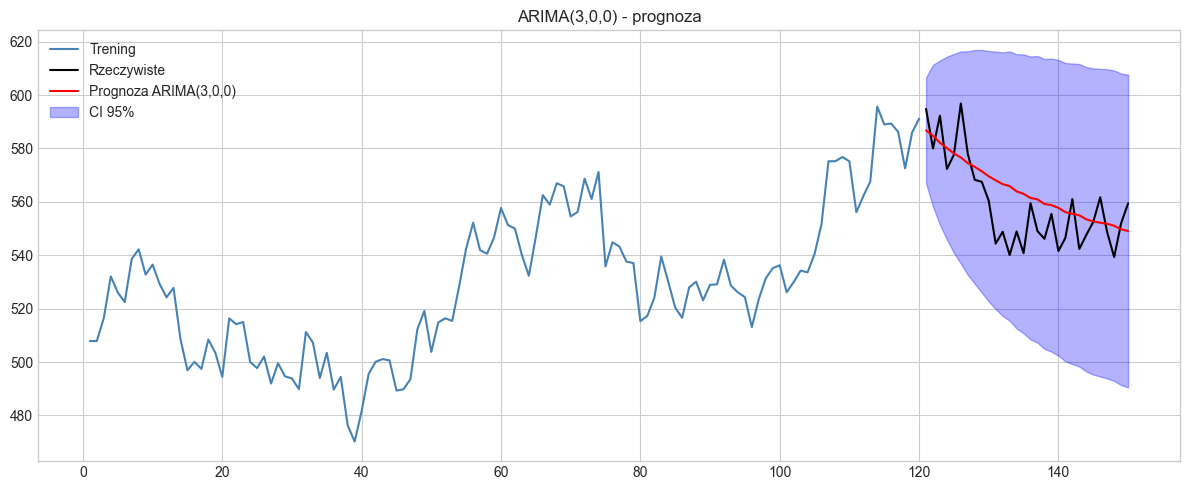

In [49]:
# Auto ARIMA - odpowiednik auto.arima z R (pmdarima)
# pip install pmdarima
try:
    import pmdarima as pm
    model_auto = pm.auto_arima(
        train_ts['sales'],
        X=train_ts[['promo']].values,
        stepwise=False, seasonal=False,
        information_criterion='bic',
        trace=True
    )
    print(model_auto.summary())
    
    # Test autokorelacji reszt (odpowiednik Box.test)
    lb = acorr_ljungbox(model_auto.resid(), lags=10, return_df=True)
    print('\nLjung-Box (autokorelacja reszt):')
    print(lb.tail(1))
    print('p > 0.05 -> brak autokorelacji ✓')
    
    # Prognoza
    p_forecast, p_ci = model_auto.predict(
        n_periods=len(test_ts),
        X=test_ts[['promo']].values,
        return_conf_int=True
    )
    
    e_ts = test_ts['sales'].values - p_forecast
    MAE_ts = np.mean(np.abs(e_ts))
    print(f'\nMAE prognozy: {MAE_ts:.2f}')
    
    # Wykres
    full_idx = np.arange(len(ts_data))
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(train_ts['week'].values, train_ts['sales'].values, color='steelblue', label='Trening')
    ax.plot(test_ts['week'].values, test_ts['sales'].values, color='black', label='Rzeczywiste')
    ax.plot(test_ts['week'].values, p_forecast, color='red', label='Prognoza')
    ax.fill_between(test_ts['week'].values, p_ci[:, 0], p_ci[:, 1], alpha=0.3, color='blue', label='CI')
    ax.legend(); ax.set_title('ARIMA - prognoza vs rzeczywistość')
    plt.tight_layout(); plt.show()
    
except ImportError:
    print('Zainstaluj pmdarima: pip install pmdarima')
    print('Alternatywnie używamy ręcznego ARIMA(3,0,0):')
    
    model_arima = ARIMA(train_ts['sales'], order=(3, 0, 0), exog=train_ts[['promo']]).fit()
    
    lb = acorr_ljungbox(model_arima.resid, lags=10, return_df=True)
    print(lb.tail(1))
    
    forecast_obj = model_arima.get_forecast(steps=len(test_ts), exog=test_ts[['promo']])
    p_mean = forecast_obj.predicted_mean
    p_ci   = forecast_obj.conf_int()
    
    e_ts = test_ts['sales'].values - p_mean.values
    print(f'MAE: {np.mean(np.abs(e_ts)):.2f}')
    
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(train_ts['week'].values, train_ts['sales'].values, color='steelblue', label='Trening')
    ax.plot(test_ts['week'].values, test_ts['sales'].values, color='black', label='Rzeczywiste')
    ax.plot(test_ts['week'].values, p_mean.values, color='red', label='Prognoza ARIMA(3,0,0)')
    ax.fill_between(test_ts['week'].values, p_ci.iloc[:, 0], p_ci.iloc[:, 1],
                    alpha=0.3, color='blue', label='CI 95%')
    ax.legend(); ax.set_title('ARIMA(3,0,0) - prognoza')
    plt.tight_layout(); plt.show()